# UCS × BFS: rotas em transporte público com custos diferentes

**Partes 4 e 5 da apresentação**: implementação dos dois algoritmos e análise comparativa dos resultados.

> ⚠️ **Aviso:** os bairros e pontos de referência são de **João Pessoa (PB)**, mas **as linhas, os tempos de viagem e as tarifas são fictícios**. Os valores foram escolhidos para ilustrar as diferenças entre os algoritmos e não representam a rede real de transporte da cidade.

**Roteiro**

1. Introdução
2. Modelagem: grafo, funções de custo e desenho
3. **Parte 4: implementação**: BFS, UCS, demonstração e verificação de corretude
4. **Parte 5: análise e comparação**: várias viagens, custo computacional, experimento de escala, quadro teórico e conclusões

## 1. Introdução

Planejar uma viagem de ônibus, trem ou a pé é um problema de **busca de caminho em grafo**: cada parada é um nó e cada trecho que dá para fazer num único embarque é uma aresta.

Os dois algoritmos comparados aqui respondem a perguntas diferentes:

| Algoritmo | O que minimiza | Como trata os custos |
|---|---|---|
| **BFS** (busca em largura) | o **número de trechos** (arestas) | **ignora** tempo, tarifa e qualquer outro peso |
| **UCS** (busca de custo uniforme) | o **custo acumulado** $g(n)$ da origem até o nó | usa a função de custo que recebermos: tempo, tarifa ou uma combinação |

Quando todos os trechos "custam" o mesmo, as duas respostas coincidem. Em transporte público, isso quase nunca acontece: um ônibus direto pode levar 40 minutos, enquanto uma caminhada seguida de dois ônibus curtos leva 32. A pergunta deste notebook é: **quanto se perde ao usar a BFS nesse domínio, e quanto custa, computacionalmente, fazer a escolha certa com a UCS?**

In [1]:
# --- Estruturas de dados usadas pelos algoritmos (implementados do zero) ---
from collections import deque        # fila FIFO com popleft em O(1): é a fronteira da BFS
import heapq                         # heap binário (fila de prioridade): é a fronteira da UCS
import itertools                     # itertools.count() gera o contador de desempate da heap
from dataclasses import dataclass    # para agrupar o resultado de uma busca num objeto legível
import math                          # math.inf como "custo ainda desconhecido" e math.isclose p/ comparar floats

# --- Experimentos e medições ---
import random                        # grades aleatórias do experimento de escala (com semente fixa)
import time                          # perf_counter_ns: relógio de alta resolução para cronometrar

# --- Análise e visualização (fora dos algoritmos) ---
import pandas as pd                  # tabelas de resultados
import matplotlib.pyplot as plt      # gráficos
from matplotlib.lines import Line2D  # itens de legenda "manuais" para o desenho do grafo
from matplotlib.patches import Patch, FancyBboxPatch  # legendas com hachura e "caixas" dos diagramas
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm  # escalas de cor sequenciais
from matplotlib.cm import ScalarMappable  # barra de cores para escalas desenhadas "à mão"
import networkx as nx                # SÓ para desenhar o grafo e para validar a UCS com Dijkstra

# Configurações de exibição: tabelas mais largas e figuras com resolução boa para o GitHub
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)
plt.rcParams.update({
    "figure.dpi": 110,               # nitidez razoável sem deixar o .ipynb pesado demais
    "axes.spines.top": False,        # eixos "limpos": só esquerda e base
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,               # grade discreta, para não competir com os dados
    "font.size": 10,
})

# Paleta categórica validada para daltonismo (azul, laranja, verde-água, violeta).
# A MESMA cor representa o MESMO algoritmo em todas as figuras do notebook.
COR_BFS = "#2a78d6"
COR_UCS_TEMPO = "#eb6834"
COR_UCS_TARIFA = "#1baf7a"
COR_UCS_GENERALIZADO = "#4a3aa7"
CORES_ALGO = {"BFS": COR_BFS, "UCS (tempo)": COR_UCS_TEMPO,
              "UCS (tarifa)": COR_UCS_TARIFA, "UCS (generalizado)": COR_UCS_GENERALIZADO}
# Codificação redundante à cor (acessibilidade): cada algoritmo também tem forma e hachura próprias
MARCADORES_ALGO = {"BFS": "o", "UCS (tempo)": "s", "UCS (tarifa)": "D", "UCS (generalizado)": "^"}
HACHURAS_ALGO = {"BFS": "///", "UCS (tempo)": "...", "UCS (tarifa)": "xx", "UCS (generalizado)": "\\\\\\"}

# Cores dos ESTADOS de um nó durante a busca (usadas nos diagramas passo a passo)
COR_EXPANDIDO = "#52514e"   # cinza-escuro: já saiu da fronteira e teve os vizinhos gerados
COR_FRONTEIRA = "#eda100"   # âmbar: descoberto, esperando na fronteira
COR_NAO_VISTO = "#ffffff"   # branco: a busca ainda não chegou lá
COR_DESTINO = "#008300"     # verde: borda que marca o destino
TINTA = "#0b0b0b"           # texto principal
TINTA_SUAVE = "#52514e"     # texto secundário (rótulos, eixos)

### Guia visual

As mesmas cores e formas se repetem em todas as figuras do notebook:

| Elemento | Codificação |
|---|---|
| **BFS** | azul · círculo ● · hachura `///` |
| **UCS (tempo)** | laranja · quadrado ■ · hachura `...` |
| **UCS (tarifa)** | verde-água · losango ◆ · hachura `xx` |
| **UCS (generalizado)** | violeta · triângulo ▲ · hachura `\\\` |
| Nó **não visitado** | etiqueta branca |
| Nó **na fronteira** | etiqueta âmbar |
| Nó **expandido** | etiqueta cinza-escura |
| **Destino** | borda verde |
| Trecho de **ônibus / trem / a pé** | cinza contínuo / violeta traço-ponto / verde pontilhado |

## 2. Modelagem

### 2.1 Dados da rede

O grafo é **não-direcionado**: dá para ir e voltar por qualquer trecho com o mesmo tempo e a mesma tarifa. Cada aresta representa **um embarque sem baldeação**, ou seja, um trecho de uma linha de ônibus, do trem ou uma caminhada.

Cada aresta tem quatro atributos:

- `tempo`: minutos de viagem;
- `tarifa`: reais pagos pelo embarque (caminhada = R$ 0,00; trem = R$ 0,50; ônibus = R$ 5,00);
- `modo`: `ônibus`, `trem` ou `a pé`;
- `linha`: identificador (fictício) da linha.

In [2]:
# Cada tupla: (parada A, parada B, tempo em min, tarifa em R$, modo, linha).
# A ORDEM importa: ela define a ordem dos vizinhos na lista de adjacência e, portanto,
# a ordem em que a BFS descobre os nós (e qual rota ela devolve quando há empate em nº de trechos).
ARESTAS = [
    ("UFPB", "Castelo Branco", 5, 0.00, "a pé", "caminhada"),
    ("UFPB", "Lagoa", 25, 5.00, "ônibus", "L101"),
    ("UFPB", "Bancários", 12, 5.00, "ônibus", "L201"),
    ("Castelo Branco", "Torre", 15, 5.00, "ônibus", "L102"),
    ("Castelo Branco", "Tambaú", 40, 5.00, "ônibus", "L510"),
    ("Torre", "Tambaú", 12, 5.00, "ônibus", "L103"),
    ("Torre", "Lagoa", 10, 5.00, "ônibus", "L102"),
    ("Bancários", "Mangabeira", 10, 5.00, "ônibus", "L201"),
    ("Bancários", "Cabo Branco", 20, 5.00, "ônibus", "L202"),
    ("Mangabeira", "Valentina", 12, 5.00, "ônibus", "L301"),
    ("Valentina", "Lagoa", 45, 5.00, "ônibus", "L302"),
    ("Cabo Branco", "Tambaú", 15, 0.00, "a pé", "caminhada"),
    ("Tambaú", "Manaíra", 8, 5.00, "ônibus", "L104"),
    ("Manaíra", "Bessa", 10, 5.00, "ônibus", "L104"),
    ("Bessa", "Cabedelo", 20, 5.00, "ônibus", "L105"),
    ("Lagoa", "Tambaú", 25, 5.00, "ônibus", "L106"),
    ("Lagoa", "Manaíra", 30, 5.00, "ônibus", "L107"),
    ("Lagoa", "Rodoviária", 8, 0.00, "a pé", "caminhada"),
    ("Lagoa", "Cruz das Armas", 15, 5.00, "ônibus", "L401"),
    ("Rodoviária", "Estação Ferroviária", 5, 0.00, "a pé", "caminhada"),
    ("Estação Ferroviária", "Bayeux", 12, 0.50, "trem", "Trem"),
    ("Estação Ferroviária", "Cabedelo", 45, 0.50, "trem", "Trem"),
    ("Cruz das Armas", "Bayeux", 15, 5.00, "ônibus", "L402"),
]

# Visão tabular dos dados, útil para conferir com os slides
pd.DataFrame(ARESTAS, columns=["parada A", "parada B", "tempo (min)", "tarifa (R$)", "modo", "linha"])

,parada A,parada B,tempo (min),tarifa (R$),modo,linha
0,UFPB,Castelo Branco,5,0.0,a pé,caminhada
1,UFPB,Lagoa,25,5.0,ônibus,L101
2,UFPB,Bancários,12,5.0,ônibus,L201
3,Castelo Branco,Torre,15,5.0,ônibus,L102
4,Castelo Branco,Tambaú,40,5.0,ônibus,L510
5,Torre,Tambaú,12,5.0,ônibus,L103
6,Torre,Lagoa,10,5.0,ônibus,L102
7,Bancários,Mangabeira,10,5.0,ônibus,L201
8,Bancários,Cabo Branco,20,5.0,ônibus,L202
9,Mangabeira,Valentina,12,5.0,ônibus,L301


### 2.2 Lista de adjacência

Os algoritmos trabalham sobre uma **lista de adjacência** feita à mão, sem networkx:

```
parada -> [(vizinho, {"tempo": ..., "tarifa": ..., "modo": ..., "linha": ...}), ...]
```

É a representação natural para busca: para expandir um nó, basta percorrer a lista dos seus vizinhos, em tempo proporcional ao grau do nó.

In [3]:
def construir_grafo(arestas):
    # dict comum (não defaultdict) para que consultar uma parada inexistente dê erro,
    # em vez de criar silenciosamente uma parada vazia
    grafo = {}
    for a, b, tempo, tarifa, modo, linha in arestas:
        # Os atributos ficam num dict para que as funções de custo possam escolher
        # qual campo usar, sem os algoritmos precisarem saber quais campos existem
        atributos = {"tempo": tempo, "tarifa": tarifa, "modo": modo, "linha": linha}
        # setdefault cria a lista de vizinhos na primeira vez que a parada aparece
        grafo.setdefault(a, []).append((b, atributos))
        # Grafo NÃO-direcionado: o mesmo trecho vale nos dois sentidos.
        # Os dois sentidos compartilham o MESMO dict de atributos, o que não é problema
        # porque os algoritmos só leem os atributos, nunca os alteram.
        grafo.setdefault(b, []).append((a, atributos))
    return grafo


grafo = construir_grafo(ARESTAS)

print(f"Paradas: {len(grafo)} | trechos (arestas não-direcionadas): {len(ARESTAS)}")
print(f"Grau médio: {sum(len(v) for v in grafo.values()) / len(grafo):.2f} vizinhos por parada\n")
# Mostra um pedaço da lista de adjacência para ilustrar o formato
for vizinho, atributos in grafo["UFPB"]:
    print(f"UFPB -> {vizinho:<15} {atributos}")

Paradas: 16 | trechos (arestas não-direcionadas): 23
Grau médio: 2.88 vizinhos por parada

UFPB -> Castelo Branco  {'tempo': 5, 'tarifa': 0.0, 'modo': 'a pé', 'linha': 'caminhada'}
UFPB -> Lagoa           {'tempo': 25, 'tarifa': 5.0, 'modo': 'ônibus', 'linha': 'L101'}
UFPB -> Bancários       {'tempo': 12, 'tarifa': 5.0, 'modo': 'ônibus', 'linha': 'L201'}


### 2.3 Funções de custo

A UCS recebe **a função de custo como parâmetro**. Assim, o mesmo algoritmo responde a perguntas diferentes:

| Função | Custo de um trecho | Pergunta que responde |
|---|---|---|
| `custo_tempo` | minutos | *Qual é a rota mais rápida?* |
| `custo_tarifa` | reais | *Qual é a rota mais barata?* |
| `custo_generalizado` | tempo + `VALOR_TEMPO` × tarifa | *Qual rota equilibra tempo e dinheiro?* |
| `custo_unitario` | 1 | *Qual rota tem menos trechos?* (a pergunta da BFS) |

O **custo generalizado** é comum em planejamento de transporte: ele converte dinheiro em tempo equivalente. Com `VALOR_TEMPO = 6`, o passageiro considera que pagar R\$ 1,00 "dói" tanto quanto 6 minutos a mais de viagem. Uma passagem de ônibus de R\$ 5,00 pesa, então, como 30 minutos.

In [4]:
# Quantos minutos equivalem a R$ 1,00 para o passageiro (parâmetro de preferência, não um dado da rede)
VALOR_TEMPO = 6


def custo_tempo(aresta):
    # Minimizar a soma dos tempos = rota mais rápida
    return aresta["tempo"]


def custo_tarifa(aresta):
    # Minimizar a soma das tarifas = rota mais barata (caminhadas são grátis)
    return aresta["tarifa"]


def custo_generalizado(aresta):
    # Converte a tarifa em "minutos equivalentes" para somar grandezas na mesma unidade
    return aresta["tempo"] + VALOR_TEMPO * aresta["tarifa"]


def custo_unitario(aresta):
    # Todo trecho vale 1: a UCS passa a minimizar o nº de trechos, exatamente como a BFS
    return 1


# Os três critérios "reais" do domínio, usados nas comparações da Parte 5
CRITERIOS = {"tempo": custo_tempo, "tarifa": custo_tarifa, "generalizado": custo_generalizado}

# Exemplo: o mesmo trecho visto por cada função de custo
exemplo = grafo["UFPB"][1][1]   # UFPB – Lagoa (ônibus L101)
print("Trecho UFPB – Lagoa:", exemplo)
for nome, f in {**CRITERIOS, "unitario": custo_unitario}.items():
    print(f"  custo_{nome:<13} = {f(exemplo)}")

Trecho UFPB – Lagoa: {'tempo': 25, 'tarifa': 5.0, 'modo': 'ônibus', 'linha': 'L101'}
  custo_tempo         = 25
  custo_tarifa        = 5.0
  custo_generalizado  = 55.0
  custo_unitario      = 1


### 2.4 Desenho do grafo

O desenho usa o `networkx` apenas como ferramenta gráfica. As **posições são fixas** e aproximam a geografia de João Pessoa: o litoral (Cabo Branco, Tambaú, Manaíra, Bessa) fica a **leste**, Bayeux a **oeste** e Cabedelo ao **norte**. As distâncias no desenho **não** são proporcionais aos tempos.

- **Cor por modo**: ônibus em cinza-escuro, trem em violeta e caminhada em verde **pontilhado**.
- Cada aresta mostra o **tempo** e a **tarifa**.
- `desenhar_grafo(rotas=...)` destaca rotas encontradas. As rotas ficam por cima da rede: a primeira **larga e translúcida**, a segunda **mais fina, por cima dela**, para os trechos em comum continuarem visíveis.

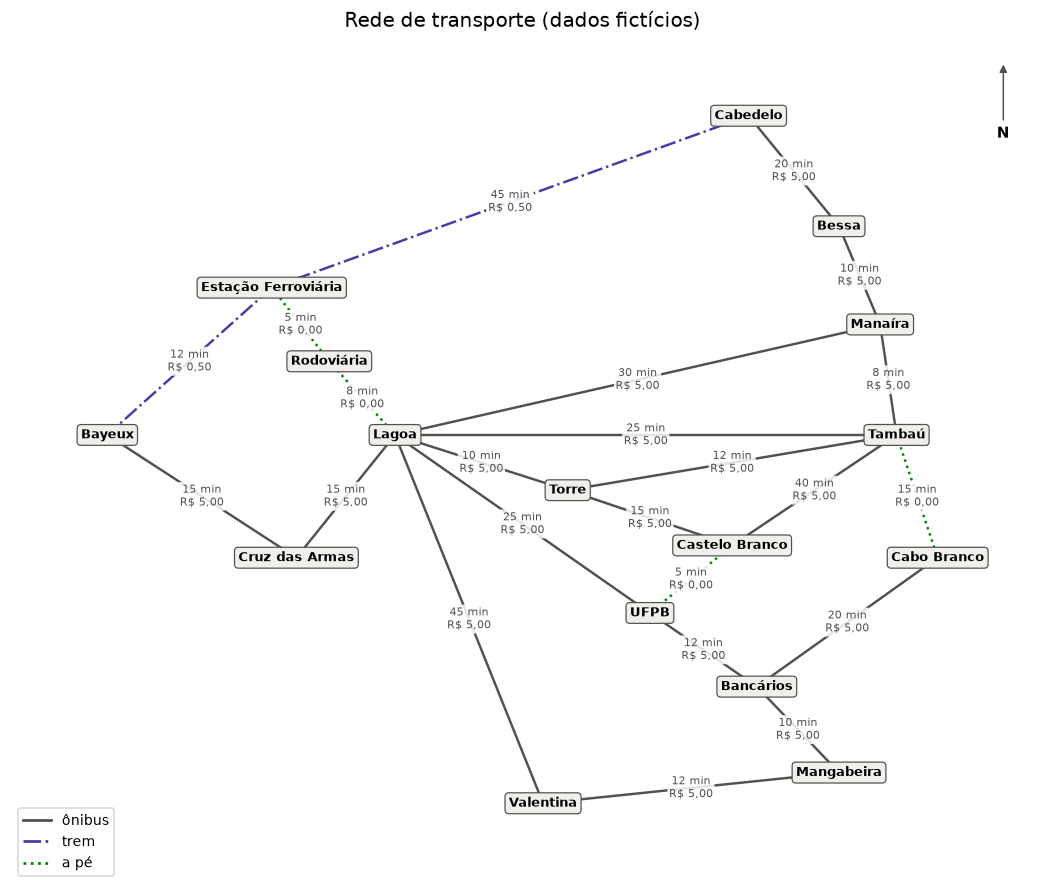

In [5]:
# Posições (x = oeste→leste, y = sul→norte) que aproximam o mapa da cidade
POSICOES = {
    "Cabedelo": (7.8, 10.2),
    "Bessa": (8.9, 8.4),
    "Manaíra": (9.4, 6.8),
    "Tambaú": (9.6, 5.0),
    "Cabo Branco": (10.1, 3.0),
    "Torre": (5.6, 4.1),
    "Castelo Branco": (7.6, 3.2),
    "UFPB": (6.6, 2.1),
    "Bancários": (7.9, 0.9),
    "Mangabeira": (8.9, -0.5),
    "Valentina": (5.3, -1.0),
    "Lagoa": (3.5, 5.0),
    "Rodoviária": (2.7, 6.2),
    "Estação Ferroviária": (2.0, 7.4),
    "Cruz das Armas": (2.3, 3.0),
    "Bayeux": (0.0, 5.0),
}
# Garante que nenhuma parada ficou sem posição (erro de digitação nos nomes, por exemplo)
assert set(POSICOES) == set(grafo), set(POSICOES) ^ set(grafo)

# Nomes curtos para os diagramas pequenos (painéis passo a passo, itinerários), onde o nome inteiro não cabe
ABREV = {
    "UFPB": "UFPB", "Castelo Branco": "C. Branco", "Lagoa": "Lagoa", "Bancários": "Bancários",
    "Torre": "Torre", "Tambaú": "Tambaú", "Mangabeira": "Mangabeira", "Cabo Branco": "Cabo Br.",
    "Valentina": "Valentina", "Manaíra": "Manaíra", "Bessa": "Bessa", "Cabedelo": "Cabedelo",
    "Rodoviária": "Rodoviária", "Cruz das Armas": "C. Armas", "Estação Ferroviária": "Estação",
    "Bayeux": "Bayeux",
}

# Estilo de cada modo: cor + tipo de linha (a caminhada é pontilhada, então não depende só da cor)
ESTILO_MODO = {
    "ônibus": {"cor": "#52514e", "linha": "solid"},
    "trem": {"cor": "#4a3aa7", "linha": "dashdot"},
    "a pé": {"cor": "#008300", "linha": "dotted"},
}

# Grafo do networkx com os MESMOS dados. Serve para desenhar aqui e para validar a UCS na Parte 4.
G = nx.Graph()
for a, b, tempo, tarifa, modo, linha in ARESTAS:
    G.add_edge(a, b, tempo=tempo, tarifa=tarifa, modo=modo, linha=linha)


def brl(valor):
    # Formata em reais no padrão brasileiro (vírgula decimal): 5.0 -> "R$ 5,00"
    return f"R$ {valor:.2f}".replace(".", ",")


def desenhar_grafo(rotas=(), titulo="Rede de transporte (dados fictícios)", ax=None, rotulos="completo"):
    # rotas: sequência de (Resultado, cor, rótulo). A 1ª é larga e translúcida; as seguintes, finas por cima.
    # rotulos: o que escrever em cada aresta: "completo" (tempo + tarifa), "tempo" ou "unitario" (sempre 1)
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 10))

    # 1) Rede completa, um modo de cada vez (cada modo tem cor e tipo de linha próprios)
    for modo, estilo in ESTILO_MODO.items():
        arestas_modo = [(a, b) for a, b, d in G.edges(data=True) if d["modo"] == modo]
        nx.draw_networkx_edges(G, POSICOES, edgelist=arestas_modo, ax=ax, edge_color=estilo["cor"],
                               style=estilo["linha"], width=1.6)

    # 2) Destaque das rotas POR CIMA da rede (mas por baixo dos rótulos, desenhados depois)
    larguras = [13, 4.5, 2]               # cada rota seguinte é mais fina que a anterior
    transparencias = [0.5, 1.0, 1.0]     # a primeira é translúcida: a rede e a rota de cima continuam visíveis
    itens_legenda_rotas = []
    for i, (res, cor, rotulo) in enumerate(rotas):
        trechos = list(zip(res.caminho, res.caminho[1:]))  # pares consecutivos = arestas da rota
        nx.draw_networkx_edges(G, POSICOES, edgelist=trechos, ax=ax, edge_color=cor,
                               width=larguras[i], alpha=transparencias[i])
        itens_legenda_rotas.append(Line2D([], [], color=cor, lw=larguras[i] * 0.6,
                                          alpha=transparencias[i], label=rotulo))

    # 3) Rótulo no meio de cada aresta: muda conforme o "ponto de vista" pedido
    formatos = {
        "completo": lambda d: f"{d['tempo']} min\n{brl(d['tarifa'])}",
        "tempo": lambda d: f"{d['tempo']} min",
        "unitario": lambda d: "1",   # para a BFS, todo trecho "custa" o mesmo
    }
    rotulos_arestas = {(a, b): formatos[rotulos](d) for a, b, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, POSICOES, edge_labels=rotulos_arestas, ax=ax,
                                 font_size=7 if rotulos == "completo" else 9,
                                 font_color="#52514e", rotate=False,
                                 bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.85})

    # 4) Paradas por cima de tudo, com o nome dentro de uma "etiqueta"
    nx.draw_networkx_labels(G, POSICOES, ax=ax, font_size=8.5, font_weight="bold",
                            bbox={"boxstyle": "round,pad=0.3", "fc": "#f0efec", "ec": "#52514e", "lw": 0.8})

    # Legenda: modos (sempre) + rotas destacadas (se houver)
    itens_modos = [Line2D([], [], color=e["cor"], ls=e["linha"], lw=1.8, label=m) for m, e in ESTILO_MODO.items()]
    ax.legend(handles=itens_modos + itens_legenda_rotas, loc="lower left", frameon=True, fontsize=9)

    # Rosa dos ventos mínima, para reforçar que as posições seguem a geografia
    ax.annotate("N", xy=(0.97, 0.97), xytext=(0.97, 0.88), xycoords="axes fraction",
                ha="center", fontweight="bold", arrowprops={"arrowstyle": "-|>", "color": "#52514e"})
    ax.set_title(titulo, fontsize=13)
    ax.grid(False)       # grade não faz sentido num desenho de grafo
    ax.axis("off")
    ax.margins(0.06)     # folga para as etiquetas das bordas não serem cortadas
    return ax


desenhar_grafo()
plt.show()

#### Como cada algoritmo "enxerga" a mesma rede

A rede é a mesma, mas cada algoritmo presta atenção num número diferente em cada trecho. Para a **BFS**, todo trecho vale **1**: ela só conta embarques e caminhadas. Para a **UCS (tempo)**, cada trecho vale **os seus minutos**. O trecho direto Castelo Branco – Tambaú (L510) mostra a diferença: para a BFS ele custa 1, o mesmo que Torre – Tambaú. Para a UCS ele custa 40, mais que o triplo dos 12 minutos de Torre – Tambaú.

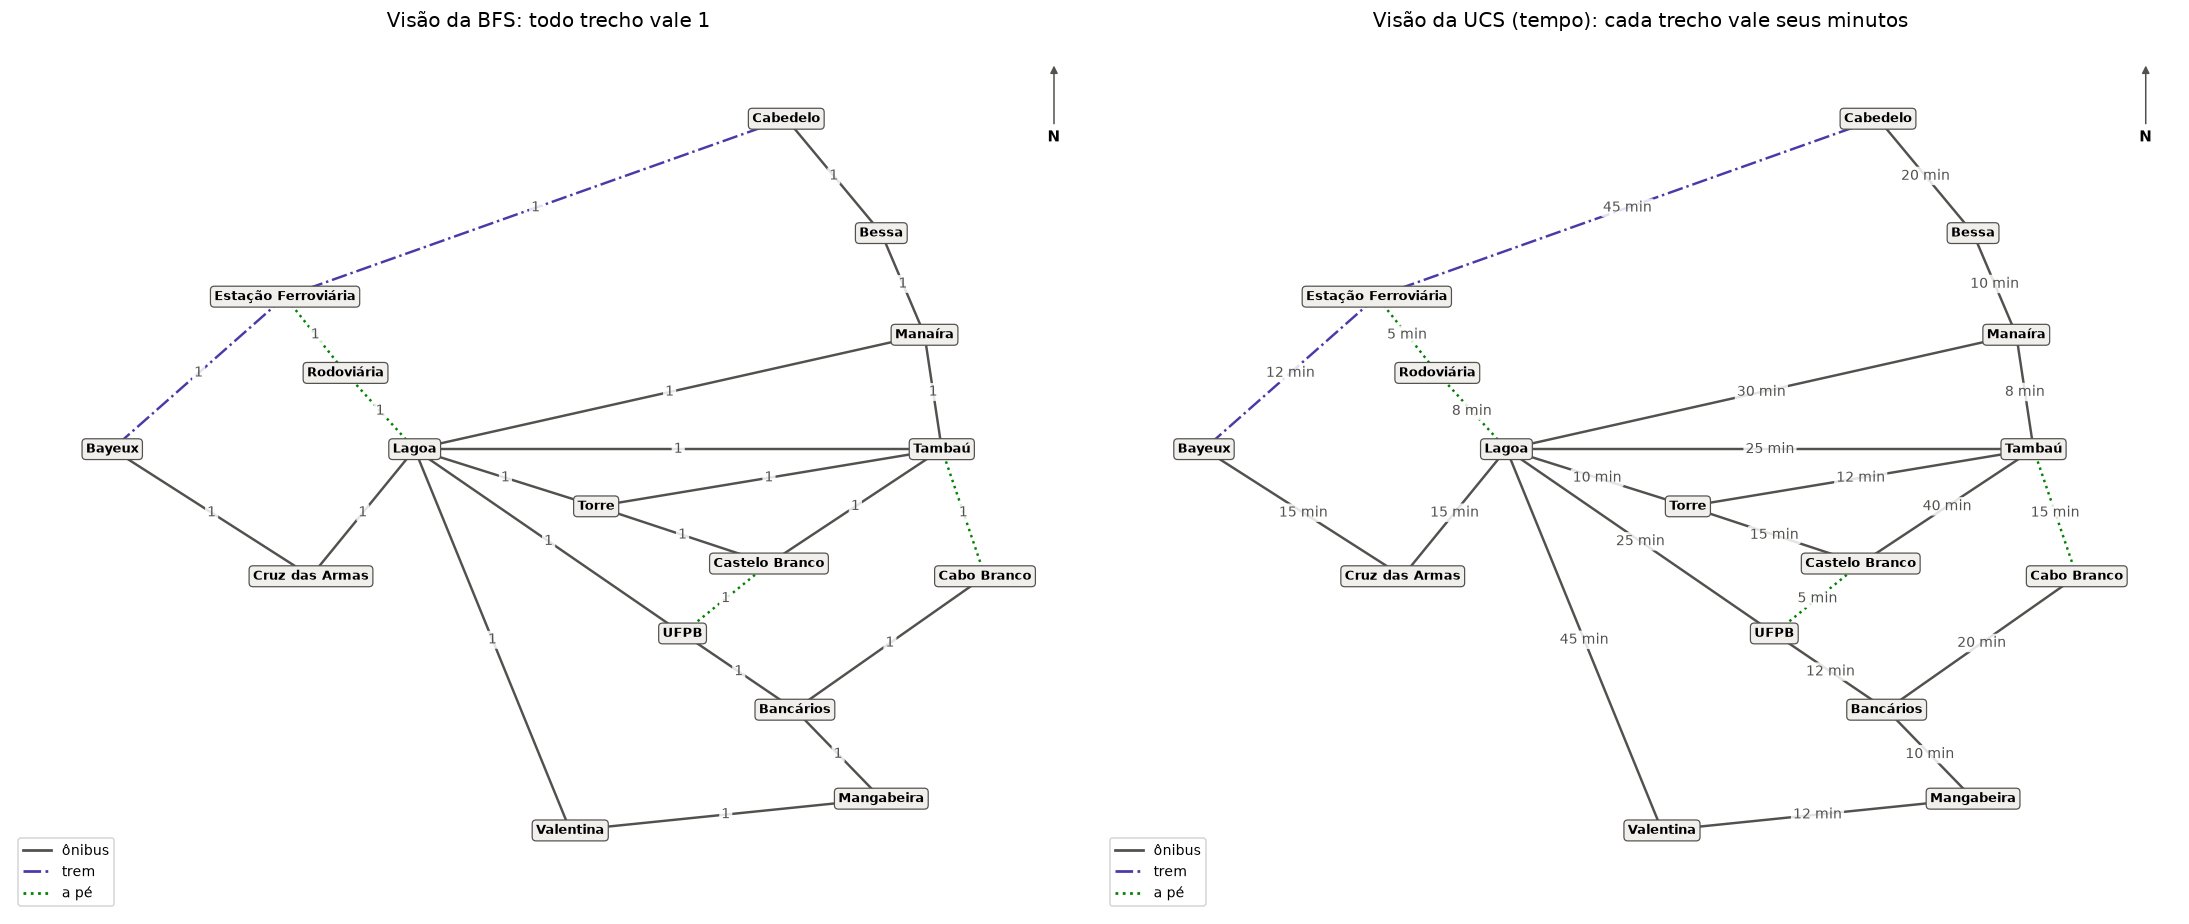

In [6]:
fig, (ax_bfs, ax_ucs) = plt.subplots(1, 2, figsize=(20, 8.5))
desenhar_grafo(ax=ax_bfs, rotulos="unitario", titulo="Visão da BFS: todo trecho vale 1")
desenhar_grafo(ax=ax_ucs, rotulos="tempo", titulo="Visão da UCS (tempo): cada trecho vale seus minutos")
fig.tight_layout()
plt.show()

---
# Parte 4: Implementação

Os dois algoritmos compartilham a mesma "moldura":

- a **fronteira** guarda os nós descobertos que ainda não foram expandidos;
- **expandir** um nó significa retirá-lo da fronteira e gerar os seus vizinhos;
- o dicionário **`pai`** guarda, para cada nó alcançado, de onde viemos e por qual trecho. Com ele, reconstruímos a rota no final.

A diferença está em só **dois pontos**, destacados nos fluxogramas abaixo:

1. **Qual nó sai da fronteira:** o mais antigo (fila FIFO) na BFS × o de menor custo acumulado $g$ (heap) na UCS.
2. **Quando se testa se chegamos:** na **geração** do vizinho na BFS × na **expansão** (quando sai da heap) na UCS.

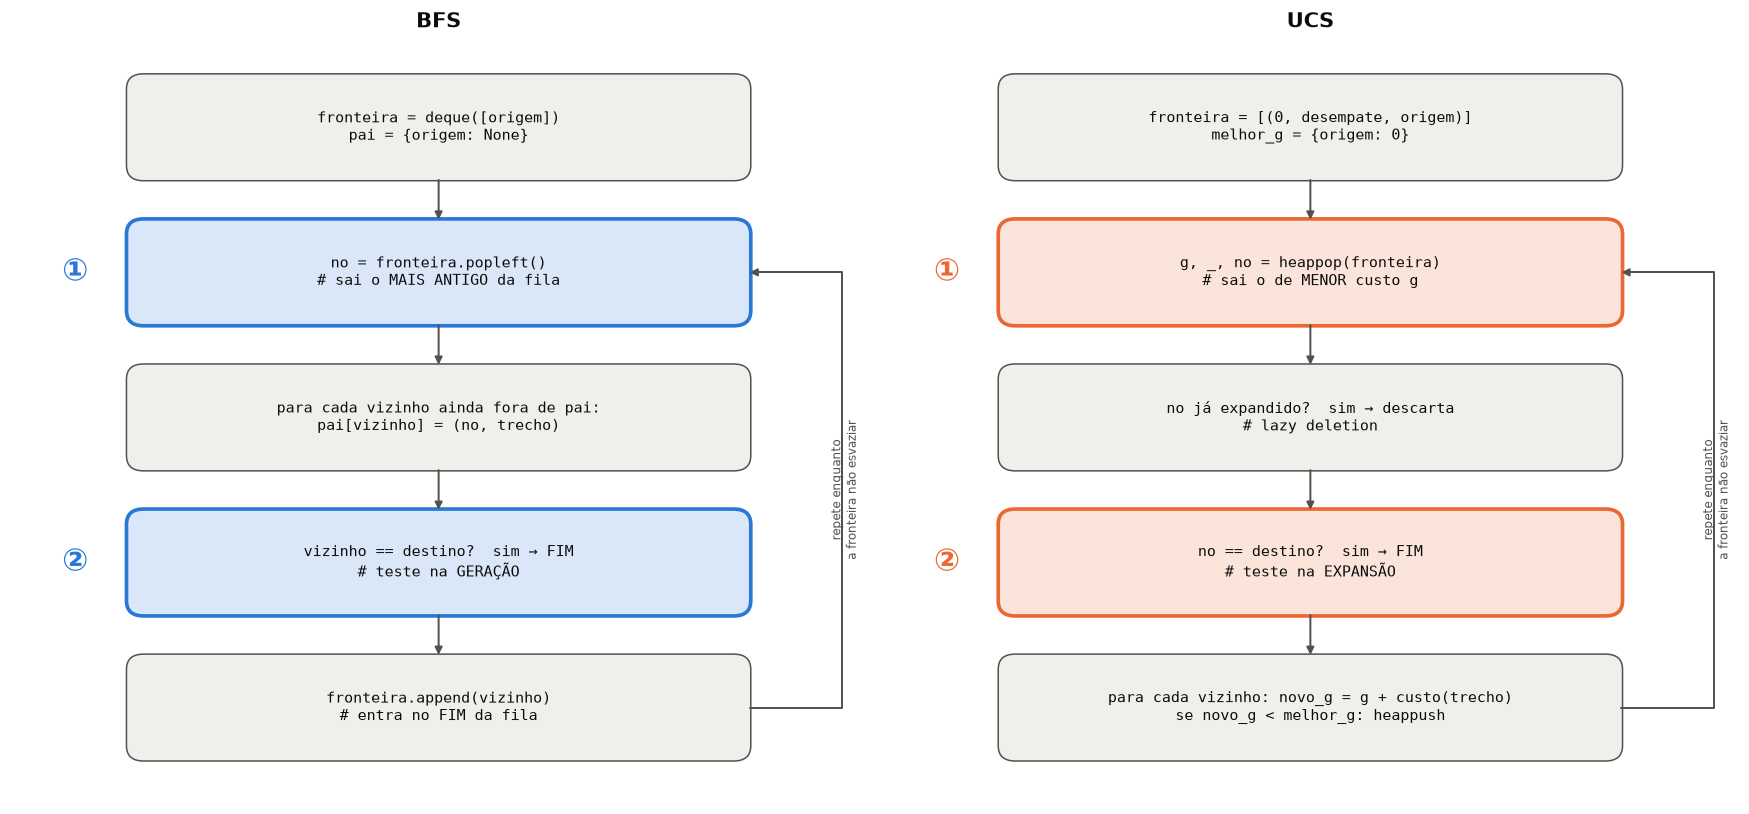

In [7]:
def clarear(cor, fracao=0.82):
    # Mistura a cor com branco: vira um fundo suave que destaca sem atrapalhar a leitura do texto
    r, g, b = (int(cor[i:i + 2], 16) / 255 for i in (1, 3, 5))
    return (r + (1 - r) * fracao, g + (1 - g) * fracao, b + (1 - b) * fracao)


def desenhar_fluxograma(ax, titulo, cor, caixas):
    # caixas: lista de (texto, marca); marca = "①"/"②" nas caixas em que os algoritmos diferem, senão None
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(titulo, fontsize=14, color=TINTA, pad=8, fontweight="bold")
    altura, passo, topo = 0.13, 0.19, 0.95          # altura das caixas, distância entre elas e topo da 1ª
    centros = [topo - altura / 2 - i * passo for i in range(len(caixas))]
    for (texto, marca), y in zip(caixas, centros):
        destaque = marca is not None
        # Caixas que diferem entre os algoritmos ganham fundo e borda na cor do algoritmo
        ax.add_patch(FancyBboxPatch((0.14, y - altura / 2), 0.72, altura,
                                    boxstyle="round,pad=0.005,rounding_size=0.02",
                                    fc=clarear(cor) if destaque else "#f0efec",
                                    ec=cor if destaque else TINTA_SUAVE, lw=2.4 if destaque else 1))
        ax.text(0.5, y, texto, ha="center", va="center", fontsize=9.5, color=TINTA, family="monospace")
        if destaque:
            # "Selo" numerado: liga a caixa à lista de diferenças do texto
            ax.text(0.075, y, marca, ha="center", va="center", fontsize=20, color=cor, fontweight="bold")
    # Setas do fluxo normal, de cima para baixo
    for y1, y2 in zip(centros, centros[1:]):
        ax.annotate("", xy=(0.5, y2 + altura / 2), xytext=(0.5, y1 - altura / 2),
                    arrowprops={"arrowstyle": "-|>", "color": TINTA_SUAVE, "lw": 1.3})
    # Seta de retorno (o laço while): da última caixa de volta à retirada da fronteira
    ax.annotate("", xy=(0.86, centros[1]), xytext=(0.86, centros[-1]),
                arrowprops={"arrowstyle": "-|>", "color": TINTA_SUAVE, "lw": 1.3,
                            "connectionstyle": "bar,fraction=0.22"})
    ax.text(0.975, (centros[1] + centros[-1]) / 2, "repete enquanto\na fronteira não esvaziar",
            rotation=90, ha="center", va="center", fontsize=8, color=TINTA_SUAVE)


fig, (ax_b, ax_u) = plt.subplots(1, 2, figsize=(16, 7.5))
desenhar_fluxograma(ax_b, "BFS", COR_BFS, [
    ("fronteira = deque([origem])\npai = {origem: None}", None),
    ("no = fronteira.popleft()\n# sai o MAIS ANTIGO da fila", "①"),
    ("para cada vizinho ainda fora de pai:\npai[vizinho] = (no, trecho)", None),
    ("vizinho == destino?  sim → FIM\n# teste na GERAÇÃO", "②"),
    ("fronteira.append(vizinho)\n# entra no FIM da fila", None),
])
desenhar_fluxograma(ax_u, "UCS", COR_UCS_TEMPO, [
    ("fronteira = [(0, desempate, origem)]\nmelhor_g = {origem: 0}", None),
    ("g, _, no = heappop(fronteira)\n# sai o de MENOR custo g", "①"),
    ("no já expandido?  sim → descarta\n# lazy deletion", None),
    ("no == destino?  sim → FIM\n# teste na EXPANSÃO", "②"),
    ("para cada vizinho: novo_g = g + custo(trecho)\nse novo_g < melhor_g: heappush", None),
])
fig.tight_layout()
plt.show()

### 4.1 Resultado de uma busca e reconstrução da rota

Para comparar os algoritmos de forma justa, os dois devolvem o mesmo objeto `Resultado`, com três métricas de esforço:

| Métrica | Definição usada aqui |
|---|---|
| `expandidos` | nós retirados da fronteira que tiveram os vizinhos gerados |
| `gerados` | entradas inseridas na fronteira, incluindo a origem. Na UCS, contam também as reinserções de um nó com custo melhor |
| `max_fronteira` | maior tamanho que a fronteira atingiu, um indicador de uso de memória |

In [8]:
@dataclass
class Resultado:
    algoritmo: str        # nome exibido nas tabelas, ex.: "BFS" ou "UCS (tempo)"
    caminho: list         # paradas da origem ao destino; lista vazia se não houver rota
    arestas: list         # atributos de cada trecho percorrido (len(arestas) == len(caminho) - 1)
    expandidos: int       # esforço: nós expandidos
    gerados: int          # esforço: inserções na fronteira
    max_fronteira: int    # memória: pico de tamanho da fronteira


def reconstruir(pai, destino):
    # Se o destino nunca foi alcançado, não há rota: devolve listas vazias em vez de falhar
    if destino not in pai:
        return [], []
    caminho, arestas = [destino], []
    no = destino
    # Sobe pelos "ponteiros" pai até a origem, que é o único nó com pai None
    while pai[no] is not None:
        anterior, atributos = pai[no]
        arestas.append(atributos)    # guarda o trecho usado para chegar em `no`
        caminho.append(anterior)
        no = anterior
    # A subida produziu a rota de trás para frente (destino → origem); invertemos
    caminho.reverse()
    arestas.reverse()
    return caminho, arestas

### 4.2 BFS: busca em largura

- **Fronteira:** `collections.deque` usada como **fila FIFO**. `append` insere no fim e `popleft` remove do início, ambos em $O(1)$. Uma `list` com `pop(0)` custaria $O(n)$ por remoção.
- **Conjunto de alcançados:** o próprio dicionário `pai`. Um nó entra em `pai` no momento em que é **gerado** e nunca é gerado de novo. Por isso não precisamos de um `set` separado de visitados.
- **Teste de objetivo na geração:** assim que o destino aparece como vizinho, a busca termina, **sem esperar ele sair da fila**.

**Por que o teste na geração é válido aqui?** A BFS expande os nós em ordem não-decrescente de profundidade, ou seja, de número de trechos desde a origem. Suponha que o destino seja gerado pela primeira vez ao expandirmos um nó de profundidade $k$. Então:

1. todos os nós de profundidade $< k$ já foram expandidos antes, e nenhum deles tinha o destino como vizinho. Se tivesse, o destino teria sido gerado antes;
2. logo, o destino **não** está a $\le k$ trechos da origem, e a profundidade $k+1$ encontrada agora é a **mínima possível**.

Testar só na expansão devolveria a mesma rota, mas antes a busca geraria **o nível $d$ inteiro** (até $b^{d}$ nós a mais, com $b$ = fator de ramificação). O teste antecipado vale porque, para a BFS, **todo trecho custa 1**. Com custos diferentes, esse argumento deixa de valer, como mostra a UCS a seguir.

> **Parâmetro `observar` (só para visualização):** os dois algoritmos aceitam uma função opcional que é chamada nos momentos importantes da busca: quando um nó é expandido, gerado, descartado ou é o destino. Ela só **lê** o estado, sem alterar nada. Com `observar=None`, que é o padrão, o algoritmo roda exatamente como sem o parâmetro. É com esse gancho que desenhamos a busca passo a passo.

In [9]:
def bfs(grafo, origem, destino, observar=None):
    # Caso trivial: já estamos no destino; rota de 0 trechos, nada a expandir
    if origem == destino:
        return Resultado("BFS", [origem], [], expandidos=0, gerados=1, max_fronteira=1)

    fronteira = deque([origem])   # fila FIFO: quem entrou primeiro (mais raso) sai primeiro
    pai = {origem: None}          # nó -> (nó anterior, atributos do trecho); também é o conjunto de alcançados
    expandidos, gerados, max_fronteira = 0, 1, 1   # a origem já conta como gerada e está na fronteira

    while fronteira:
        no = fronteira.popleft()  # o nó mais antigo da fila = o de menor profundidade ainda não expandido
        expandidos += 1
        if observar is not None:  # gancho de visualização: só avisa, não muda nada
            observar("expande", no, None, fronteira, pai)
        for vizinho, atributos in grafo[no]:
            # Já alcançado antes? Então ele já tem um caminho com nº de trechos <= ao atual; ignoramos
            if vizinho in pai:
                continue
            pai[vizinho] = (no, atributos)   # marca como alcançado NA GERAÇÃO e guarda por onde chegamos
            gerados += 1
            if observar is not None:
                observar("gera", vizinho, None, fronteira, pai)
            # Teste de objetivo NA GERAÇÃO: válido porque todos os trechos "custam" 1 (ver explicação acima)
            if vizinho == destino:
                if observar is not None:
                    observar("objetivo", vizinho, None, fronteira, pai)
                caminho, arestas = reconstruir(pai, destino)
                return Resultado("BFS", caminho, arestas, expandidos, gerados, max_fronteira)
            fronteira.append(vizinho)        # entra no FIM da fila: será expandido depois de todo o nível atual
            max_fronteira = max(max_fronteira, len(fronteira))

    # Fila vazia sem achar o destino: não existe rota (grafo desconexo)
    return Resultado("BFS", [], [], expandidos, gerados, max_fronteira)


# Teste rápido: rota com o menor número de trechos entre UFPB e Tambaú
res = bfs(grafo, "UFPB", "Tambaú")
print(" → ".join(res.caminho), f"| {len(res.arestas)} trechos | expandidos={res.expandidos}, gerados={res.gerados}")

UFPB → Castelo Branco → Tambaú | 2 trechos | expandidos=2, gerados=6


#### Ferramentas para ver a busca por dentro

- **`Gravador`:** um observador que "fotografa" o estado da busca **a cada nó retirado da fronteira**. Ele guarda a fronteira antes da retirada, os nós gerados no passo, a árvore `pai` e o valor de cada nó: $g$ na UCS e **nível** (nº de trechos) na BFS.
- **`desenhar_passos`:** um mapa por passo. Cada nó recebe a cor do seu estado, e as linhas escuras formam a **árvore de busca**, isto é, por qual trecho cada nó foi alcançado.
- **`desenhar_fronteiras`:** o conteúdo da fronteira em cada passo, **na ordem em que os nós vão sair**. A caixa com borda colorida é a que sai naquele passo.

In [10]:
class Gravador:
    # Observador passado para bfs/ucs: "fotografa" o estado da busca a cada nó retirado da fronteira.
    # Ele só LÊ as estruturas do algoritmo (copiando o que precisa); nunca as altera.
    def __init__(self):
        self.passos = []       # uma foto por retirada da fronteira
        self.valores = {}      # último valor conhecido de cada nó: g na UCS, nível (nº de trechos) na BFS
        self.expandidos = []   # ordem em que os nós foram expandidos

    def _entradas(self, fronteira):
        # Converte a fronteira em [(nó, valor), ...] NA ORDEM EM QUE OS NÓS VÃO SAIR
        if isinstance(fronteira, deque):
            return [(n, self.valores[n]) for n in fronteira]    # fila: a ordem interna já é a de saída
        return [(n, g) for g, _, n in sorted(fronteira)]        # heap: só a raiz é garantida; ordenamos

    def _fechar(self, fronteira_depois, pai):
        # Completa a foto do passo atual com o estado DEPOIS dele (é o que os mapas mostram)
        self.passos[-1].update(fronteira_depois=fronteira_depois, pai=dict(pai),
                               valores=dict(self.valores), expandidos=list(self.expandidos))

    def __call__(self, evento, no, g, fronteira, pai):
        eh_bfs = isinstance(fronteira, deque)
        if evento == "gera":
            # A BFS não calcula g: o "valor" do nó é o nível do pai + 1 (nº de trechos desde a origem)
            self.valores[no] = self.valores[pai[no][0]] + 1 if eh_bfs else g
            self.passos[-1]["gerados"].append((no, self.valores[no]))
            return
        if evento == "objetivo" and eh_bfs:
            # A BFS acha o destino na GERAÇÃO, ainda dentro do passo atual: só marca e fecha o passo
            self.passos[-1]["achou"] = True
            self._fechar(self._entradas(fronteira), pai)
            return
        # Daqui para baixo, um nó ACABOU de sair da fronteira (expande, descarta, ou o destino na UCS)
        valor = self.valores.setdefault(no, 0) if eh_bfs else g   # a origem entra com valor 0
        self.valores.setdefault(no, valor)
        antes = [(no, valor)] + self._entradas(fronteira)         # recoloca o nó retirado na frente
        if self.passos:
            self._fechar(antes, pai)   # o "depois" do passo anterior é o "antes" deste
        self.passos.append({"evento": evento, "no": no, "valor": valor, "fronteira_antes": antes,
                            "gerados": [], "achou": evento == "objetivo"})
        if evento == "expande":
            self.expandidos.append(no)
        if evento == "objetivo":       # UCS: o destino saiu da heap; é o último passo
            self._fechar(self._entradas(fronteira), pai)


def desenhar_estado(ax, foto, destino, cor, fmt_valor, custo=None):
    # 1) Mapa de fundo: todas as arestas bem claras (e, se pedido, o custo de cada trecho)
    for a, b, tempo, tarifa, modo, linha in ARESTAS:
        (x1, y1), (x2, y2) = POSICOES[a], POSICOES[b]
        ax.plot([x1, x2], [y1, y2], color="#d9d8d3", lw=1, zorder=1)
        if custo is not None:
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, f"{custo({'tempo': tempo, 'tarifa': tarifa}):g}",
                    fontsize=6.5, color="#9a9994", ha="center", va="center", zorder=4,   # acima da árvore
                    bbox={"boxstyle": "round,pad=0.1", "fc": "white", "ec": "none"})
    # 2) Árvore de busca: o trecho pelo qual cada nó alcançado foi alcançado (dicionário pai)
    for n, ref in foto["pai"].items():
        if ref is not None:
            (x1, y1), (x2, y2) = POSICOES[ref[0]], POSICOES[n]
            ax.plot([x1, x2], [y1, y2], color=TINTA_SUAVE, lw=2.2, zorder=2)
    # 3) Rota final, quando o destino foi encontrado neste passo
    if foto["achou"]:
        caminho, _ = reconstruir(foto["pai"], destino)
        xs, ys = zip(*(POSICOES[n] for n in caminho))
        ax.plot(xs, ys, color=cor, lw=7, alpha=0.85, zorder=3, solid_capstyle="round")
    # 4) Nós: o fundo mostra o estado; a borda mostra o papel do nó NESTE passo
    novos = {n for n, _ in foto["gerados"]}
    for n, (x, y) in POSICOES.items():
        if n in foto["expandidos"]:
            fundo, tinta = COR_EXPANDIDO, "white"
        elif n in foto["valores"]:                 # alcançado mas não expandido = esperando na fronteira
            fundo, tinta = COR_FRONTEIRA, TINTA
        else:
            fundo, tinta = COR_NAO_VISTO, "#9a9994"
        borda, espessura, estilo = "#bdbcb6", 0.8, "-"
        if n in novos:                             # descoberto (ou melhorado, na UCS) neste passo
            borda, espessura, estilo = TINTA, 1.5, "--"
        if n == destino:
            borda, espessura, estilo = COR_DESTINO, 2.4, "-"
        if n == foto.get("no"):                    # o nó retirado da fronteira neste passo
            borda, espessura, estilo = cor, 3.2, "-"
        rotulo = f"{ABREV[n]}\n{fmt_valor(foto['valores'][n])}" if n in foto["valores"] else ABREV[n]
        ax.text(x, y, rotulo, ha="center", va="center", fontsize=6.8, color=tinta, zorder=5,
                fontweight="bold", linespacing=1.1,
                bbox={"boxstyle": "round,pad=0.25", "fc": fundo, "ec": borda, "lw": espessura, "ls": estilo})
    ax.set_xlim(-1.0, 11.2)
    ax.set_ylim(-1.7, 10.9)
    ax.axis("off")


def titulo_passo(k, foto, destino, fmt_valor):
    # Linha 1: o que saiu da fronteira; linha 2: quem foi gerado (com o valor calculado)
    no, v = foto["no"], fmt_valor(foto["valor"])
    if foto["evento"] == "inicio":
        return "Início\nsó a origem na fronteira"
    if foto["evento"] == "descarta":
        return f"Passo {k}: retira {no} ({v})\nentrada obsoleta → descarta"
    if foto["evento"] == "objetivo":
        return f"Passo {k}: retira {no} ({v})\né o destino → FIM (teste na expansão)"
    gerados = " · ".join(f"{ABREV[n]} {fmt_valor(val)}" for n, val in foto["gerados"]) or "nenhum vizinho novo"
    if foto["achou"]:
        return f"Passo {k}: expande {no} ({v})\ngera {gerados} → destino! FIM"
    return f"Passo {k}: expande {no} ({v})\ngera {gerados}"


def desenhar_passos(grav, destino, cor, fmt_valor, titulo, custo=None, ncols=3):
    # Foto sintética do início: só a origem, na fronteira, com valor 0
    origem = grav.passos[0]["no"]
    inicio = {"evento": "inicio", "no": None, "valor": 0, "gerados": [], "achou": False,
              "pai": {origem: None}, "valores": {origem: 0}, "expandidos": [], "fronteira_depois": [(origem, 0)]}
    fotos = [inicio] + grav.passos
    nlin = math.ceil(len(fotos) / ncols)
    fig, eixos = plt.subplots(nlin, ncols, figsize=(5.3 * ncols, 5.2 * nlin), squeeze=False)
    for k, (ax, foto) in enumerate(zip(eixos.flat, fotos)):
        desenhar_estado(ax, foto, destino, cor, fmt_valor, custo)
        ax.set_title(titulo_passo(k, foto, destino, fmt_valor), fontsize=9.5, color=TINTA, loc="left")
    for ax in list(eixos.flat)[len(fotos):]:     # painéis sobrando na grade ficam vazios
        ax.axis("off")
    legenda = [
        Patch(fc=COR_NAO_VISTO, ec="#bdbcb6", label="não visitado"),
        Patch(fc=COR_FRONTEIRA, ec="#bdbcb6", label="na fronteira"),
        Patch(fc=COR_EXPANDIDO, label="expandido"),
        Patch(fc="white", ec=cor, lw=2.5, label="retirado neste passo"),
        Patch(fc="white", ec=TINTA, lw=1.5, ls="--", label="gerado neste passo"),
        Patch(fc="white", ec=COR_DESTINO, lw=2, label="destino"),
        Line2D([], [], color=TINTA_SUAVE, lw=2.2, label="árvore de busca (pai)"),
        Line2D([], [], color=cor, lw=5, alpha=0.85, label="rota final"),
    ]
    fig.legend(handles=legenda, loc="lower center", ncol=4, frameon=False, fontsize=9.5)
    fig.suptitle(titulo, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=(0, 0.06 if nlin == 1 else 0.035, 1, 0.97))
    return fig


def desenhar_fronteiras(grav, destino, cor, fmt_valor, titulo, explicacao):
    passos = grav.passos
    largura, altura, folga = 1.45, 0.66, 0.12      # tamanho de cada caixa e espaço entre caixas
    max_itens = max(len(f["fronteira_antes"]) for f in passos)
    x_acao = max_itens * (largura + folga) + 0.3    # coluna onde escrevemos a ação do passo
    fig, ax = plt.subplots(figsize=(min(17, 0.95 * (x_acao + 6.8)), 0.78 * len(passos) + 1.6))
    for k, foto in enumerate(passos, start=1):
        y = -k
        ja_expandidos = set(passos[k - 2]["expandidos"]) if k > 1 else set()
        vistos = set()
        ax.text(-0.25, y, f"passo {k}", ha="right", va="center", fontsize=9.5, color=TINTA_SUAVE)
        for i, (n, v) in enumerate(foto["fronteira_antes"]):
            # Entrada obsoleta (só na UCS): o nó já foi expandido, ou há entrada melhor dele mais à frente
            obsoleta = n in ja_expandidos or n in vistos
            vistos.add(n)
            x = i * (largura + folga)
            retirada = i == 0          # a primeira caixa é a que sai neste passo
            borda, espessura = "#bdbcb6", 0.8
            if n == destino:
                borda, espessura = COR_DESTINO, 2.2
            if retirada:
                borda, espessura = cor, 3.2
            ax.add_patch(FancyBboxPatch((x, y - altura / 2), largura, altura,
                                        boxstyle="round,pad=0,rounding_size=0.1",
                                        fc="white" if obsoleta else COR_FRONTEIRA, ec=borda, lw=espessura,
                                        hatch="////" if obsoleta else None))
            ax.text(x + largura / 2, y, f"{ABREV[n]}\n{fmt_valor(v)}", ha="center", va="center",
                    fontsize=8.3, color="#8a8984" if obsoleta else TINTA, linespacing=1.1,
                    fontweight="bold" if n == destino else "normal",
                    bbox={"boxstyle": "round,pad=0.05", "fc": "white", "ec": "none"} if obsoleta else None)
        # Ação tomada com o nó retirado
        no = ABREV[foto["no"]]
        acao = {"expande": f"→ expande {no}", "descarta": f"→ {no} obsoleta: descarta",
                "objetivo": f"→ {no} é o destino: FIM"}[foto["evento"]]
        if foto["achou"] and foto["evento"] == "expande":
            acao += f"; gera {ABREV[destino]} = destino: FIM"
        ax.text(x_acao, y, acao, va="center", fontsize=9.5, color=TINTA,
                fontweight="bold" if foto["achou"] else "normal")
    # Indicação de por onde os nós saem
    ax.annotate("sai por aqui", xy=(largura / 2, -0.55), xytext=(largura / 2, 0.05), ha="center",
                fontsize=9, color=cor, fontweight="bold",
                arrowprops={"arrowstyle": "-|>", "color": cor, "lw": 1.5})
    ax.text(x_acao, 0.1, explicacao, fontsize=9, color=TINTA_SUAVE, va="bottom")
    ax.set_xlim(-1.3, x_acao + 5.5)
    ax.set_ylim(-len(passos) - 0.6, 0.75)
    ax.axis("off")
    ax.set_title(titulo, fontsize=13, fontweight="bold", loc="left")
    fig.tight_layout()
    return fig

#### BFS passo a passo: UFPB → Tambaú

Cada painel mostra o estado **depois** do passo. O número embaixo de cada nome é o **nível**, isto é, quantos trechos o separam da origem.

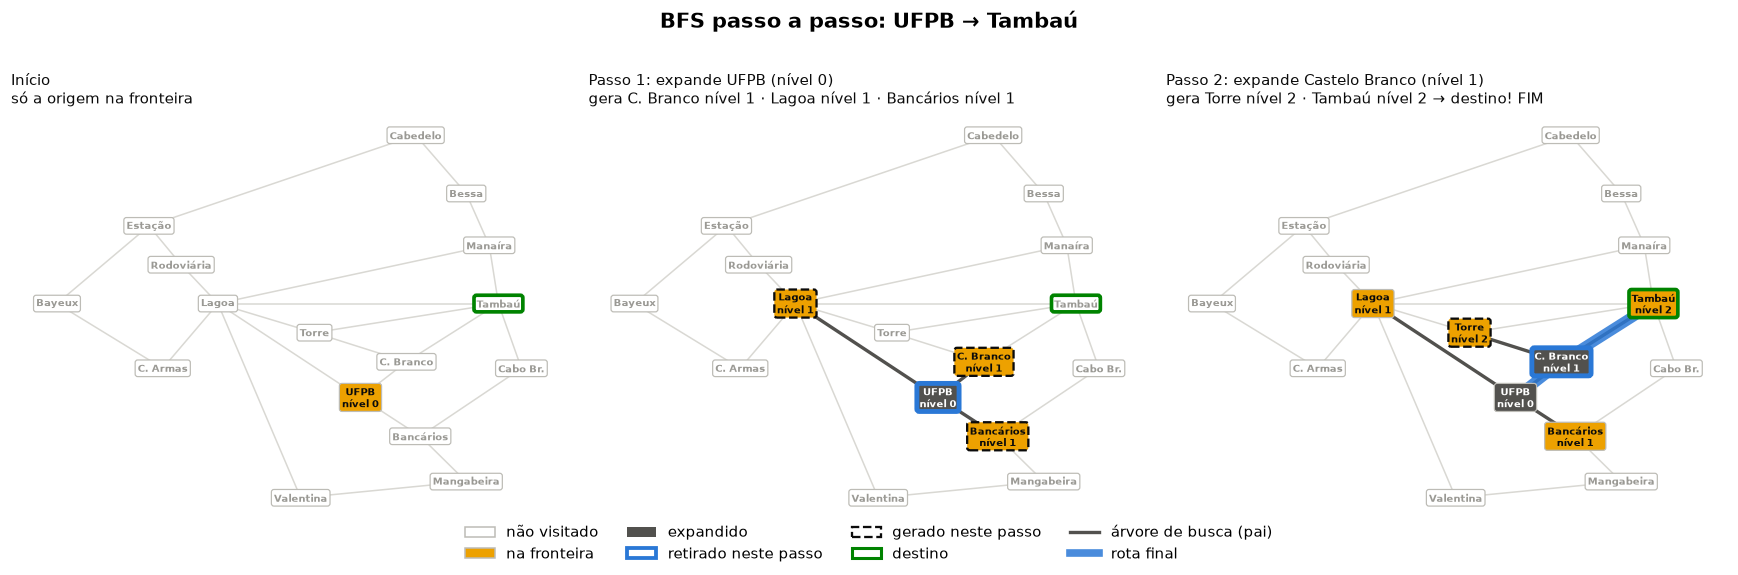

In [11]:
fmt_nivel = lambda v: f"nível {v}"           # como a BFS "rotula" um nó: pela profundidade
grav_bfs = Gravador()
bfs(grafo, "UFPB", "Tambaú", observar=grav_bfs)
desenhar_passos(grav_bfs, "Tambaú", COR_BFS, fmt_nivel, "BFS passo a passo: UFPB → Tambaú")
plt.show()

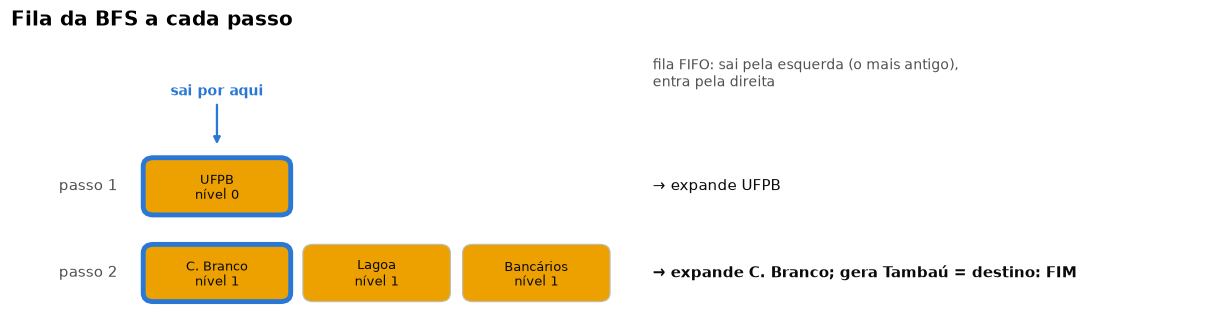

In [12]:
desenhar_fronteiras(grav_bfs, "Tambaú", COR_BFS, fmt_nivel, "Fila da BFS a cada passo",
                    "fila FIFO: sai pela esquerda (o mais antigo),\nentra pela direita")
plt.show()

A fila fica **ordenada por nível sem nenhum esforço**: tudo que é de nível 1 entra antes de qualquer nó de nível 2. No passo 2, ao expandir Castelo Branco, a BFS **gera** Tambaú e para ali mesmo. Lagoa e Bancários ainda estavam na fila e nunca foram expandidos. Essa é a economia do teste na geração. A rota encontrada tem só **2 trechos**, mas o segundo é a linha L510, de **40 minutos**, que a BFS nem olhou.

### 4.3 UCS: busca de custo uniforme

- **Fronteira:** heap binário (`heapq`) com tuplas `(g, contador_de_desempate, nó)`. O `heappop` devolve sempre o nó com **menor custo acumulado $g$**.
- **`melhor_g`:** o menor custo conhecido até cada nó. Um vizinho só é (re)inserido se o novo caminho for **estritamente mais barato**.
- **`expandidos` com *lazy deletion*:** o `heapq` não permite diminuir a prioridade de um item que já está na heap. Quando achamos um caminho melhor, inserimos uma **nova** entrada e deixamos a antiga lá. Ao retirar da heap um nó que **já foi expandido**, a entrada está obsoleta e é simplesmente descartada.
- **Teste de objetivo na expansão:** a busca só termina quando o destino **sai** da heap.
- **Função de custo como parâmetro:** o mesmo código serve para tempo, tarifa, custo generalizado ou custo unitário.

**Por que não dá para parar na geração?** Na primeira vez que o destino é *gerado*, o caminho até ele pode não ser o mais barato, porque ainda há na fronteira nós com $g$ menor que podem levar ao destino por um caminho mais barato. Só quando o destino é *retirado* da heap temos a garantia: todo outro caminho passaria por algum nó da fronteira com $g' \ge g(\text{destino})$ e, **como os custos não são negativos**, não pode terminar mais barato. Os painéis abaixo mostram isso acontecendo na viagem UFPB → Tambaú.

**Papel do contador de desempate.** Tuplas são comparadas elemento a elemento. Quando dois nós empatam em $g$, sem o contador o Python compararia **os próprios nós**. Com strings, isso ordenaria os empates por ordem alfabética, um viés arbitrário. Com objetos não comparáveis, daria `TypeError`. O contador é único e crescente: resolve **todo** empate antes de chegar ao nó, torna a execução **determinística** e dá ordem FIFO aos empates (quem entrou primeiro sai primeiro).

**Exigência de custos não negativos.** A correção da UCS, o mesmo argumento do algoritmo de Dijkstra, depende de $g$ nunca diminuir ao longo de um caminho. Com uma aresta negativa, um nó já expandido, e portanto "fechado", poderia depois ser alcançado por um caminho mais barato, e a resposta estaria errada. Por isso a implementação **rejeita custos negativos** com um erro explícito. Custos **zero** são permitidos, como a tarifa da caminhada. Num grafo finito, o conjunto de expandidos garante que a busca termina mesmo assim.

In [13]:
def ucs(grafo, origem, destino, custo=custo_tempo, observar=None):
    # Nome derivado da função de custo: custo_tempo -> "UCS (tempo)"
    nome = f"UCS ({custo.__name__.removeprefix('custo_')})"

    contador = itertools.count()          # desempate: garante que a tupla nunca compare os nós em si
    fronteira = [(0, next(contador), origem)]   # heap de (g, desempate, nó); começa com a origem a custo 0
    melhor_g = {origem: 0}                # menor custo conhecido até cada nó (pode melhorar até ele ser expandido)
    pai = {origem: None}                  # para reconstruir a rota; atualizado sempre que melhor_g melhora
    expandidos = set()                    # nós "fechados": o g deles já é ótimo e não muda mais
    gerados, max_fronteira = 1, 1

    while fronteira:
        g, _, no = heapq.heappop(fronteira)   # retira o nó de MENOR custo acumulado
        # Lazy deletion: se o nó já foi expandido, esta é uma entrada antiga (com g pior); descarta
        if no in expandidos:
            if observar is not None:
                observar("descarta", no, g, fronteira, pai)
            continue
        # Teste de objetivo NA EXPANSÃO: ao sair da heap, g é garantidamente o custo mínimo
        if no == destino:
            if observar is not None:
                observar("objetivo", no, g, fronteira, pai)
            caminho, arestas = reconstruir(pai, destino)
            return Resultado(nome, caminho, arestas, len(expandidos), gerados, max_fronteira)
        expandidos.add(no)                # fecha o nó: nenhum caminho futuro pode ser mais barato
        if observar is not None:          # gancho de visualização: só avisa, não muda nada
            observar("expande", no, g, fronteira, pai)

        for vizinho, atributos in grafo[no]:
            if vizinho in expandidos:     # vizinho fechado: já temos o melhor caminho até ele
                continue
            c = custo(atributos)
            if c < 0:                     # custo negativo quebraria a garantia de otimalidade
                raise ValueError(f"Custo negativo ({c}) no trecho {no} – {vizinho}: a UCS exige custos >= 0")
            novo_g = g + c                # custo de chegar ao vizinho passando por `no`
            # Só vale a pena (re)inserir se o novo caminho for ESTRITAMENTE melhor que o conhecido
            if novo_g < melhor_g.get(vizinho, math.inf):
                melhor_g[vizinho] = novo_g
                pai[vizinho] = (no, atributos)
                # A entrada antiga do vizinho (se houver) continua na heap: será descartada pela lazy deletion
                heapq.heappush(fronteira, (novo_g, next(contador), vizinho))
                gerados += 1
                max_fronteira = max(max_fronteira, len(fronteira))
                if observar is not None:
                    observar("gera", vizinho, novo_g, fronteira, pai)

    # Heap vazia sem expandir o destino: não existe rota
    return Resultado(nome, [], [], len(expandidos), gerados, max_fronteira)

#### UCS (tempo) passo a passo: UFPB → Tambaú

Agora o número embaixo de cada nome é o **custo acumulado $g$** em minutos, e o custo de cada trecho aparece em cinza no meio da aresta. Vale acompanhar o destino, com a borda verde:

- no **passo 2**, Tambaú é gerado com $g = 45$, pela linha L510. Uma BFS pararia aqui;
- no **passo 4**, ao expandir Torre, a UCS acha um caminho mais barato: $g = 32$. O `pai` de Tambaú muda, e a linha escura da árvore passa a vir de Torre;
- só no **passo 8**, quando sai da heap, Tambaú está garantido como ótimo.

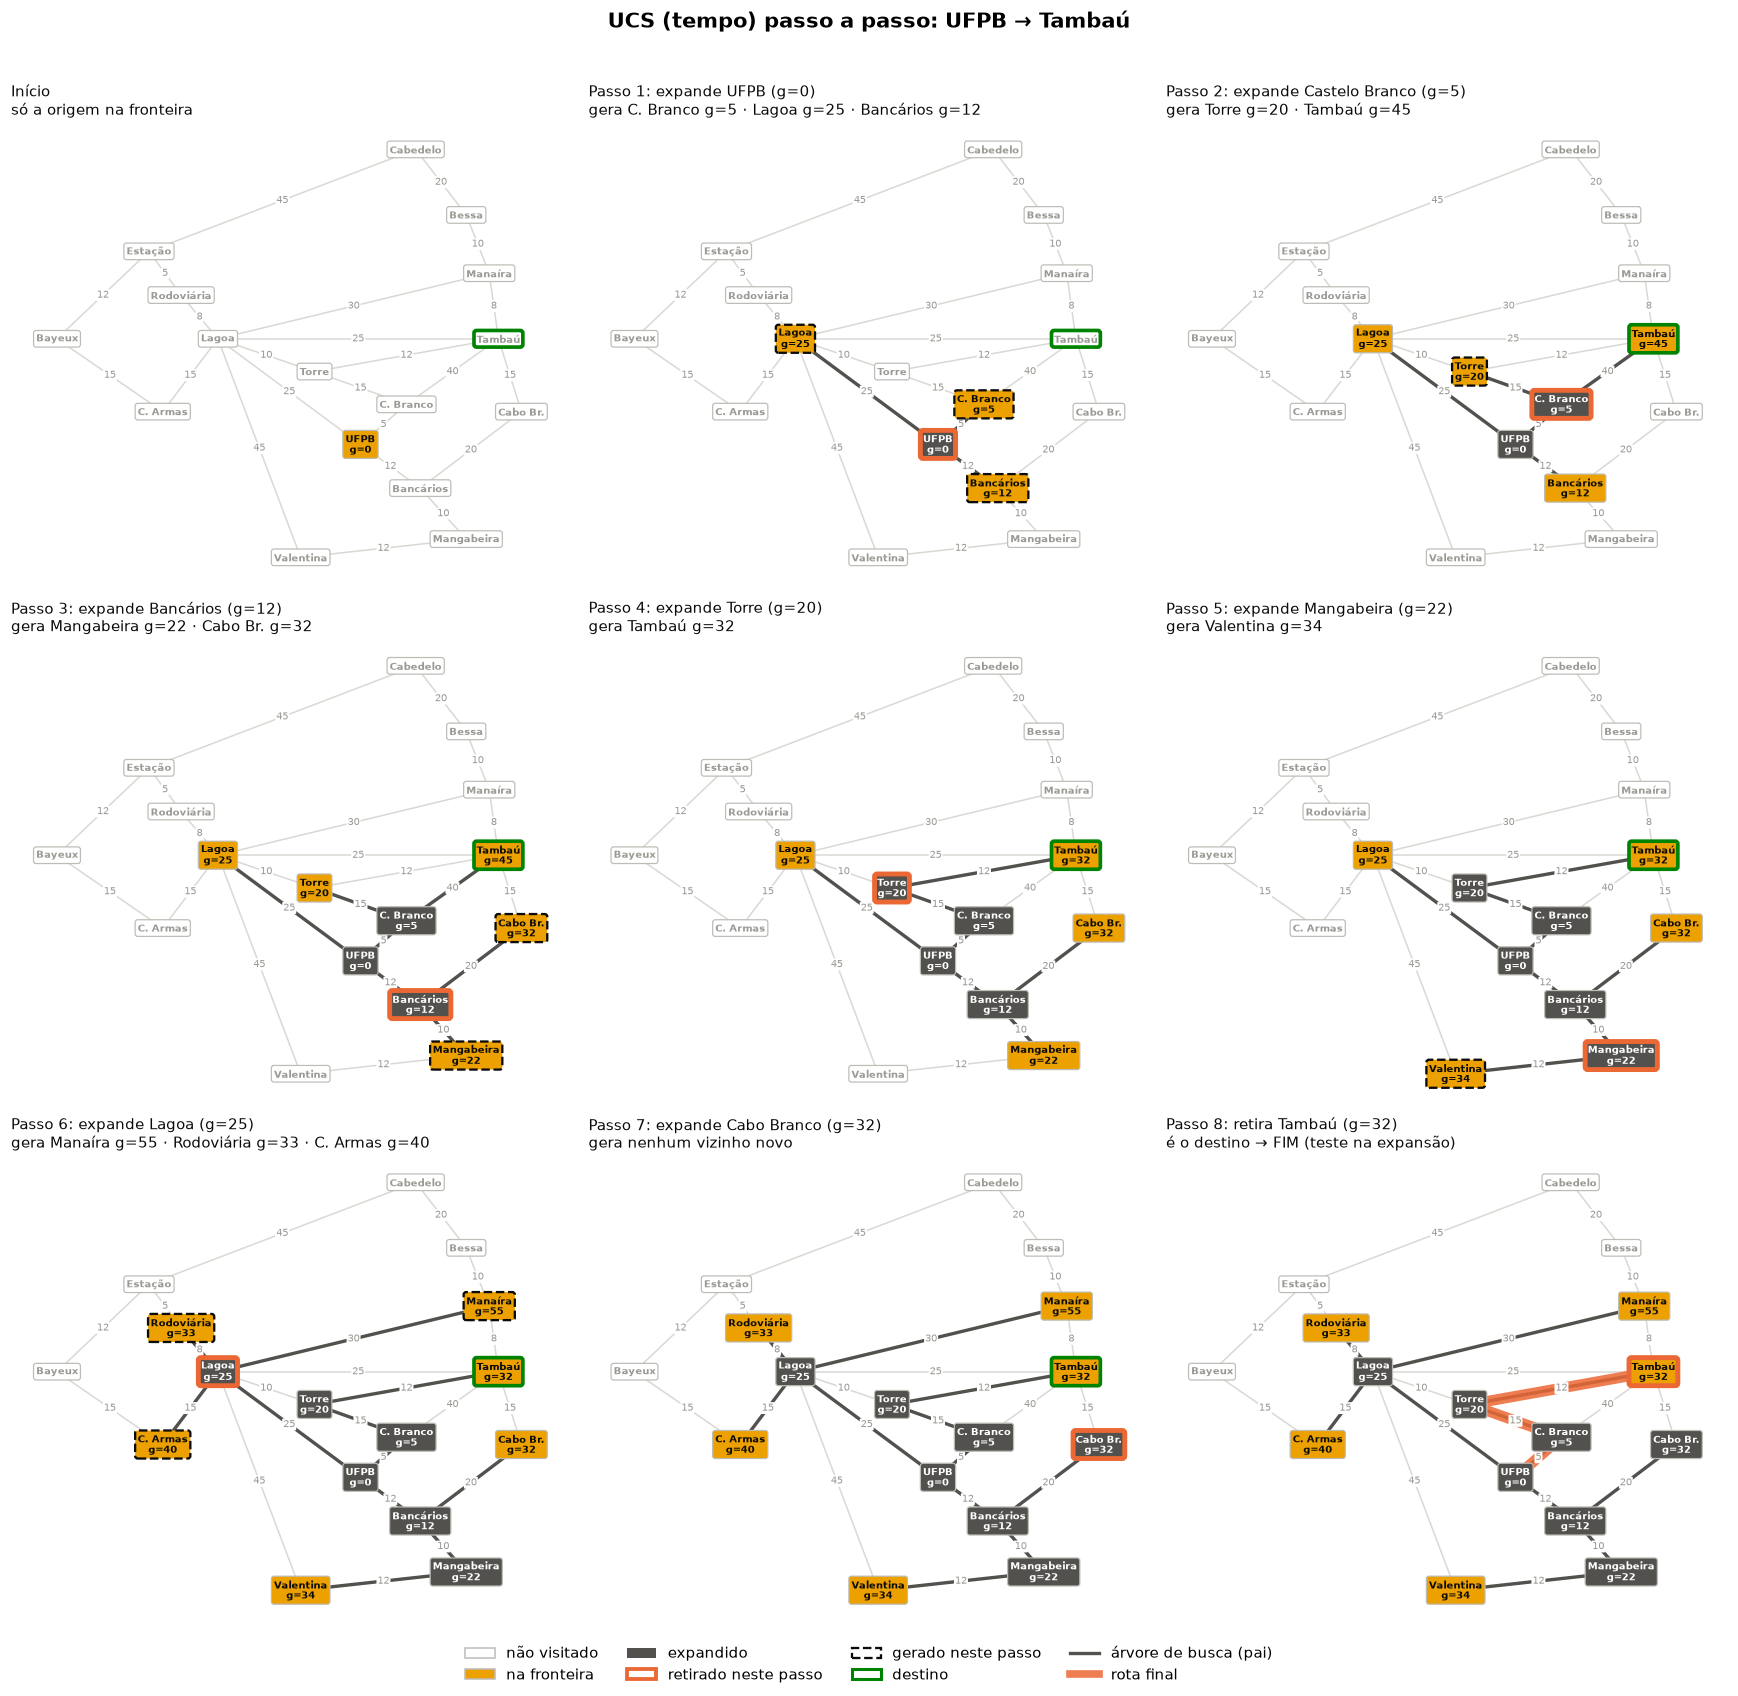

In [14]:
fmt_g = lambda v: f"g={v:g}"                 # como a UCS "rotula" um nó: pelo custo acumulado
grav_ucs = Gravador()
ucs(grafo, "UFPB", "Tambaú", custo_tempo, observar=grav_ucs)
desenhar_passos(grav_ucs, "Tambaú", COR_UCS_TEMPO, fmt_g, "UCS (tempo) passo a passo: UFPB → Tambaú",
                custo=custo_tempo)
plt.show()

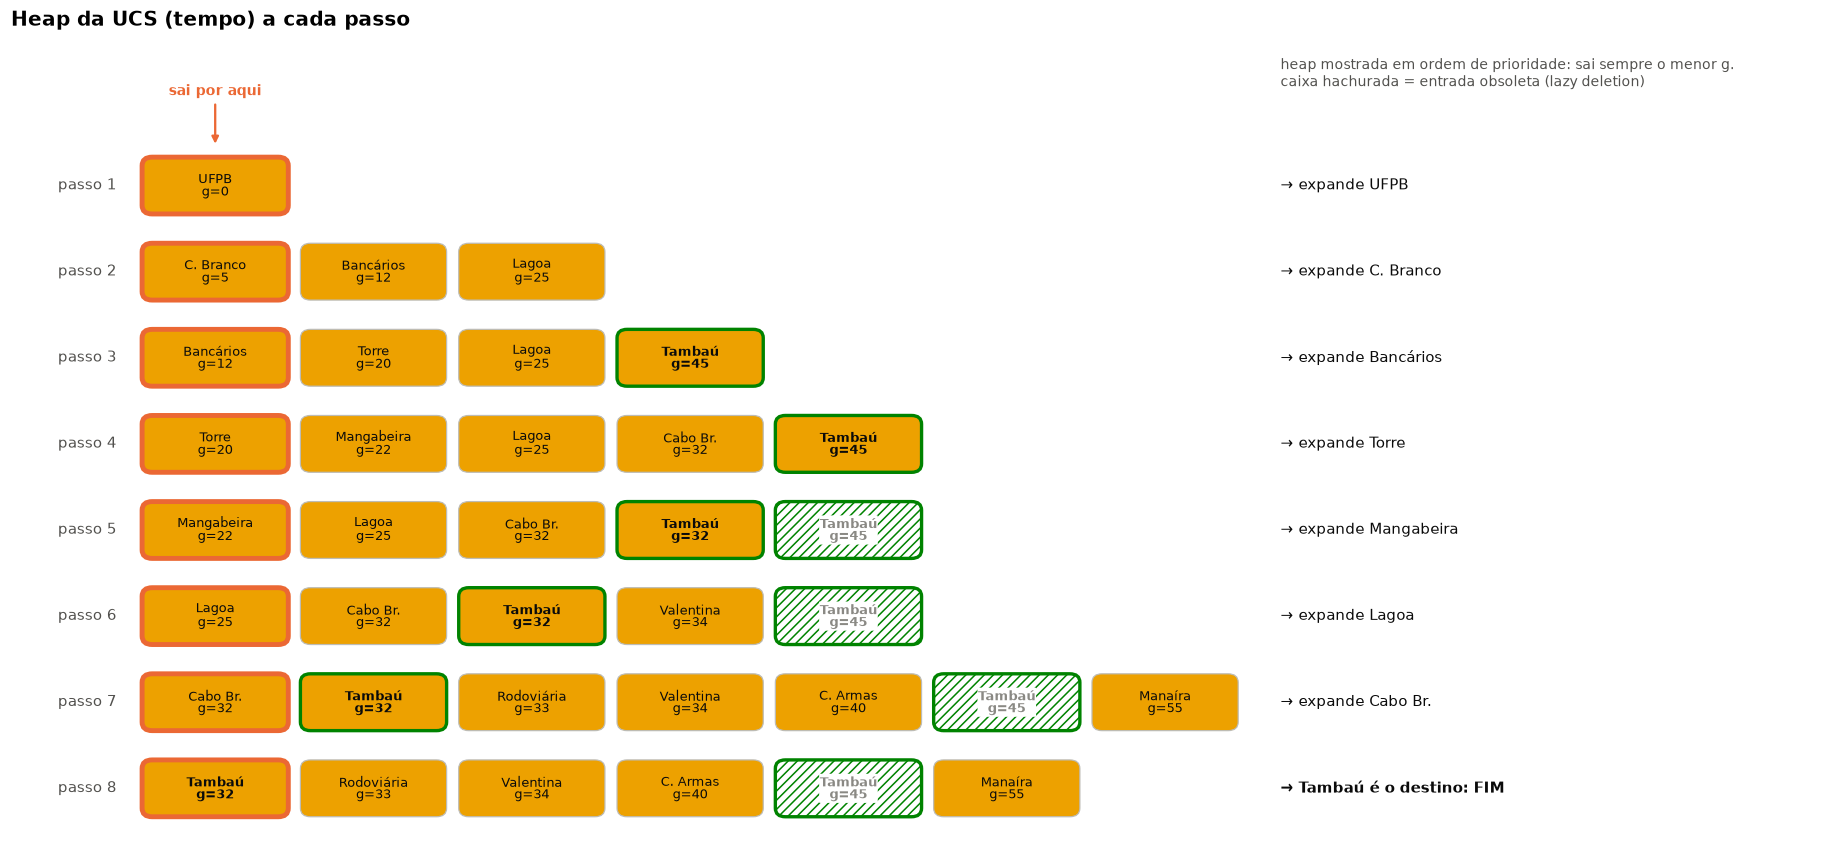

passo 2: Tambaú gerado com g = 45 (expandindo Castelo Branco)
passo 4: Tambaú gerado com g = 32 (expandindo Torre)
passo 8: Tambaú retirado da heap com g = 32 → ótimo garantido


In [15]:
desenhar_fronteiras(grav_ucs, "Tambaú", COR_UCS_TEMPO, fmt_g, "Heap da UCS (tempo) a cada passo",
                    "heap mostrada em ordem de prioridade: sai sempre o menor g.\n"
                    "caixa hachurada = entrada obsoleta (lazy deletion)")
plt.show()

# Confirma, a partir do próprio rastro, a história do destino contada acima
for k, foto in enumerate(grav_ucs.passos, start=1):
    for n, g in foto["gerados"]:
        if n == "Tambaú":
            print(f"passo {k}: Tambaú gerado com g = {g:g} (expandindo {foto['no']})")
ultimo = grav_ucs.passos[-1]
print(f"passo {len(grav_ucs.passos)}: Tambaú retirado da heap com g = {ultimo['valor']:g} → ótimo garantido")

Na heap, a entrada **Tambaú g=45** fica **hachurada** a partir do passo 5: ela continua lá dentro, mas já existe uma entrada melhor (g=32) para o mesmo nó. É exatamente a *lazy deletion*: em vez de procurar e apagar a entrada antiga, que custaria $O(n)$, a UCS a deixa lá e a descartaria quando saísse. Aqui ela nem chega a sair, porque a busca termina antes.

Repare também que a UCS expande **7 nós**, contra **2 da BFS**, e visita até Mangabeira e Lagoa, que "parecem" fora do caminho. Ela precisa ter certeza de que não existe nada mais barato que 32 minutos. Esse é o preço da garantia de otimalidade.

### 4.4 Resumo, impressão e itinerário das rotas

`resumo(res)` calcula as métricas de uma rota **independentemente do critério que a busca otimizou**. Assim, dá para ver, por exemplo, quanto custa em reais a rota mais rápida.

**Baldeações** = embarques pagos − 1. Caminhadas são grátis e não contam como embarque. Cada trecho pago é um embarque, porque cada aresta é um embarque sem baldeação.

`desenhar_itinerarios` mostra as rotas como num aplicativo de transporte: uma barra por rota, com um bloco por trecho. O **comprimento** do bloco é o tempo do trecho e a **cor** é o modo de transporte.

In [16]:
def custo_da_rota(res, custo):
    # Recalcula o custo da rota devolvida somando os trechos (não confia em nenhum valor interno da busca)
    return sum(custo(a) for a in res.arestas)


def resumo(res):
    # Sem rota: devolve só o nome e as métricas de esforço, que continuam fazendo sentido
    if not res.caminho:
        return {"algoritmo": res.algoritmo, "rota": "(sem rota)", "expandidos": res.expandidos,
                "gerados": res.gerados, "max fronteira": res.max_fronteira}
    embarques_pagos = sum(1 for a in res.arestas if a["tarifa"] > 0)   # caminhada (R$ 0) não é embarque
    return {
        "algoritmo": res.algoritmo,
        "rota": " → ".join(res.caminho),
        "trechos": len(res.arestas),
        "tempo (min)": custo_da_rota(res, custo_tempo),
        "tarifa (R$)": round(custo_da_rota(res, custo_tarifa), 2),  # round evita 5.5000000001
        "custo generalizado": round(custo_da_rota(res, custo_generalizado), 2),
        "baldeações": max(embarques_pagos - 1, 0),   # max(...) cobre rotas só a pé (0 embarques)
        "expandidos": res.expandidos,
        "gerados": res.gerados,
        "max fronteira": res.max_fronteira,
    }


def imprimir_rota(res):
    # Cabeçalho com o algoritmo e a rota completa
    print(f"=== {res.algoritmo}: {res.caminho[0] if res.caminho else '?'} → {res.caminho[-1] if res.caminho else '?'} ===")
    if not res.caminho:
        print("  Nenhuma rota encontrada.\n")
        return
    # Um trecho por linha, na ordem em que o passageiro os percorre
    for i, (a, b, atr) in enumerate(zip(res.caminho, res.caminho[1:], res.arestas), start=1):
        print(f"  {i}. {a:>19} → {b:<19} {atr['modo']:<7} {atr['linha']:<10} "
              f"{atr['tempo']:>3} min  {brl(atr['tarifa'])}")
    r = resumo(res)
    print(f"  Total: {r['trechos']} trechos | {r['tempo (min)']} min | {brl(r['tarifa (R$)'])} | "
          f"custo generalizado {r['custo generalizado']:g} | {r['baldeações']} baldeação(ões)\n")


def desenhar_itinerarios(resultados, ax=None, titulo=None, xmax=None):
    # Uma barra horizontal por rota; cada bloco é um trecho (comprimento = minutos, cor = modo)
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 1.05 * len(resultados) + 1.1))
    n = len(resultados)
    for i, res in enumerate(resultados):
        y = n - 1 - i                    # o primeiro resultado fica no topo
        t = 0                            # "relógio" da viagem: minuto em que o trecho começa
        for a, b, atr in zip(res.caminho, res.caminho[1:], res.arestas):
            estilo = ESTILO_MODO[atr["modo"]]
            a_pe = atr["modo"] == "a pé"
            # Caminhada: fundo claro pontilhado (não depende só da cor); ônibus/trem: cor sólida
            ax.barh(y, atr["tempo"], left=t, height=0.42,
                    color=clarear(estilo["cor"], 0.75) if a_pe else estilo["cor"],
                    hatch="..." if a_pe else None, edgecolor=estilo["cor"] if a_pe else "white",
                    linewidth=0.8 if a_pe else 1.5)
            if atr["tempo"] >= 6:        # só escreve a linha dentro do bloco se couber
                ax.text(t + atr["tempo"] / 2, y, "a pé" if a_pe else atr["linha"], ha="center", va="center",
                        fontsize=7.5, fontweight="bold", color=TINTA if a_pe else "white",
                        bbox={"boxstyle": "round,pad=0.1", "fc": clarear(estilo["cor"], 0.75), "ec": "none"}
                        if a_pe else None)
            # Nome da parada onde o trecho começa (inclinado para caber em trechos curtos)
            ax.text(t, y + 0.26, ABREV[a], rotation=28, ha="left", va="bottom", fontsize=7, color=TINTA_SUAVE)
            t += atr["tempo"]
        ax.text(t, y + 0.26, ABREV[res.caminho[-1]], rotation=28, ha="left", va="bottom", fontsize=7,
                color=TINTA, fontweight="bold")
        r = resumo(res)
        ax.text(t + 1.5, y - 0.02, f"{r['tempo (min)']} min · {brl(r['tarifa (R$)'])} · {r['trechos']} trechos",
                va="center", fontsize=8.5, color=TINTA)
        # Marcador do algoritmo (cor + forma): liga esta linha às outras figuras do notebook
        ax.scatter([-2.5], [y], marker=MARCADORES_ALGO.get(res.algoritmo, "o"), s=60, zorder=3, clip_on=False,
                   color=CORES_ALGO.get(res.algoritmo, TINTA_SUAVE))
    ax.set_yticks(range(n), [r.algoritmo for r in reversed(resultados)])
    ax.tick_params(axis="y", length=0, pad=16)
    ax.spines["left"].set_visible(False)
    ax.set_ylim(-0.5, n - 0.05)
    limite = xmax or max(custo_da_rota(r, custo_tempo) for r in resultados)
    ax.set_xlim(-4, limite + 42)           # folga à direita para o texto do total
    ax.set_xlabel("minutos desde a partida")
    ax.grid(axis="y", visible=False)
    if titulo:
        ax.set_title(titulo, loc="left", fontsize=12, fontweight="bold")
    return ax

### 4.5 Demonstração: UFPB → Tambaú

Executamos a BFS e a UCS com cada um dos três critérios na mesma viagem.

In [17]:
origem, destino = "UFPB", "Tambaú"
demo = {
    "BFS": bfs(grafo, origem, destino),
    **{f"UCS ({nome})": ucs(grafo, origem, destino, f) for nome, f in CRITERIOS.items()},
}

for res in demo.values():
    imprimir_rota(res)

pd.DataFrame([resumo(r) for r in demo.values()]).set_index("algoritmo")

=== BFS: UFPB → Tambaú ===
  1.                UFPB → Castelo Branco      a pé    caminhada    5 min  R$ 0,00
  2.      Castelo Branco → Tambaú              ônibus  L510        40 min  R$ 5,00
  Total: 2 trechos | 45 min | R$ 5,00 | custo generalizado 75 | 0 baldeação(ões)

=== UCS (tempo): UFPB → Tambaú ===
  1.                UFPB → Castelo Branco      a pé    caminhada    5 min  R$ 0,00
  2.      Castelo Branco → Torre               ônibus  L102        15 min  R$ 5,00
  3.               Torre → Tambaú              ônibus  L103        12 min  R$ 5,00
  Total: 3 trechos | 32 min | R$ 10,00 | custo generalizado 92 | 1 baldeação(ões)

=== UCS (tarifa): UFPB → Tambaú ===
  1.                UFPB → Castelo Branco      a pé    caminhada    5 min  R$ 0,00
  2.      Castelo Branco → Tambaú              ônibus  L510        40 min  R$ 5,00
  Total: 2 trechos | 45 min | R$ 5,00 | custo generalizado 75 | 0 baldeação(ões)

=== UCS (generalizado): UFPB → Tambaú ===
  1.                UFPB → Caste

,rota,trechos,tempo (min),tarifa (R$),custo generalizado,baldeações,expandidos,gerados,max fronteira
algoritmo,,,,,,,,,
BFS,UFPB → Castelo Branco → Tambaú,2,45,5.0,75.0,0,2,6,3
UCS (tempo),UFPB → Castelo Branco → Torre → Tambaú,3,32,10.0,92.0,1,7,13,7
UCS (tarifa),UFPB → Castelo Branco → Tambaú,2,45,5.0,75.0,0,5,12,8
UCS (generalizado),UFPB → Castelo Branco → Tambaú,2,45,5.0,75.0,0,7,15,8


In [18]:
# Confere os valores que aparecem nos slides; se algum dado mudar, o notebook falha aqui
r_bfs, r_ucs_tempo = resumo(demo["BFS"]), resumo(demo["UCS (tempo)"])
assert (r_bfs["trechos"], r_bfs["tempo (min)"]) == (2, 45), r_bfs
assert (r_ucs_tempo["trechos"], r_ucs_tempo["tempo (min)"]) == (3, 32), r_ucs_tempo
print(f"BFS:         {r_bfs['trechos']} trechos / {r_bfs['tempo (min)']} min   ✔")
print(f"UCS (tempo): {r_ucs_tempo['trechos']} trechos / {r_ucs_tempo['tempo (min)']} min   ✔")
print(f"A rota da BFS é {r_bfs['tempo (min)'] - r_ucs_tempo['tempo (min)']} min "
      f"({(r_bfs['tempo (min)'] / r_ucs_tempo['tempo (min)'] - 1):.0%}) mais lenta, apesar de ter 1 trecho a menos.")

BFS:         2 trechos / 45 min   ✔
UCS (tempo): 3 trechos / 32 min   ✔
A rota da BFS é 13 min (41%) mais lenta, apesar de ter 1 trecho a menos.


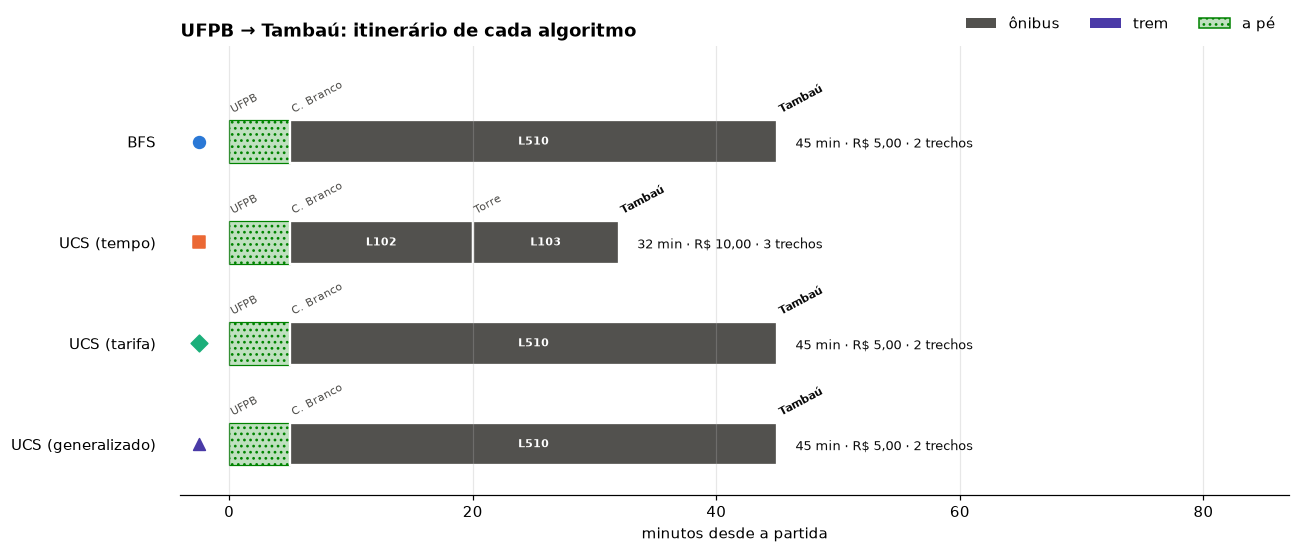

In [19]:
# Legenda dos modos (nos itinerários, a cor do bloco é o MODO de transporte, não o algoritmo)
LEGENDA_MODOS = [Patch(fc=ESTILO_MODO["ônibus"]["cor"], label="ônibus"),
                 Patch(fc=ESTILO_MODO["trem"]["cor"], label="trem"),
                 Patch(fc=clarear(ESTILO_MODO["a pé"]["cor"], 0.75), ec=ESTILO_MODO["a pé"]["cor"],
                       hatch="...", label="a pé")]

ax = desenhar_itinerarios(list(demo.values()), titulo="UFPB → Tambaú: itinerário de cada algoritmo")
ax.legend(handles=LEGENDA_MODOS, loc="lower right", bbox_to_anchor=(1, 1.0), frameon=False, ncol=3)
plt.show()

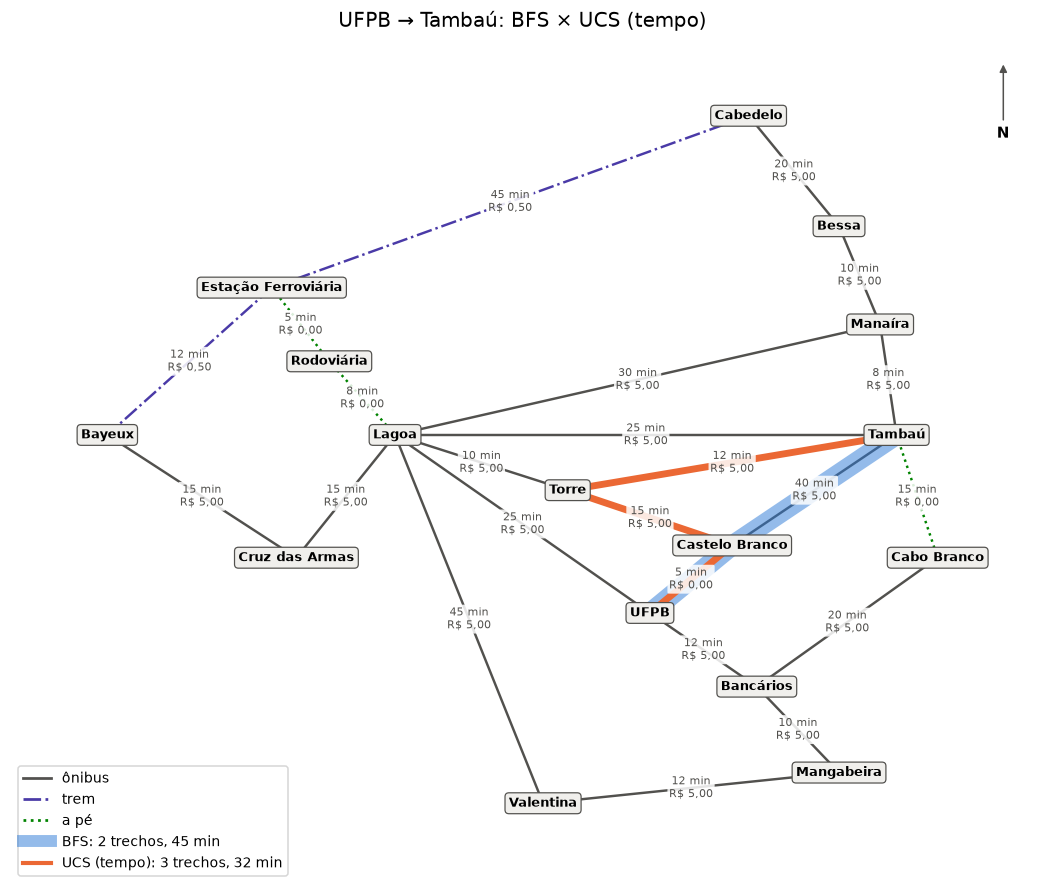

In [20]:
desenhar_grafo(
    rotas=[(demo["BFS"], COR_BFS, "BFS: 2 trechos, 45 min"),
           (demo["UCS (tempo)"], COR_UCS_TEMPO, "UCS (tempo): 3 trechos, 32 min")],
    titulo="UFPB → Tambaú: BFS × UCS (tempo)",
)
plt.show()

A **BFS** escolhe **UFPB → Castelo Branco → Tambaú**: são só 2 trechos, mas o segundo é a linha L510, de 40 minutos. A **UCS (tempo)** aceita um trecho a mais (Castelo Branco → **Torre** → Tambaú) e chega em **32 minutos**. O trecho a pé UFPB → Castelo Branco é comum às duas rotas e continua visível no desenho: a faixa larga azul fica por baixo da linha laranja.

Nesta viagem, a rota da BFS coincide com a mais **barata** (R\$ 5,00) e a de menor custo **generalizado**. Isso é coincidência dos dados, não uma propriedade da BFS, como a Parte 5 vai mostrar.

### 4.6 Ondas de busca: camadas × isócronas

Rodando os dois algoritmos a partir da UFPB para **todas** as paradas, vemos como cada um "enxerga" a distância:

- a **BFS** organiza a cidade em **camadas de trechos**: nível 1, nível 2, …;
- a **UCS (tempo)** organiza a cidade em **isócronas**, ou seja, faixas de mesmo tempo de viagem.

As linhas escuras formam a **árvore de busca**: por qual trecho cada parada é alcançada. As duas árvores diferem justamente onde a rota com menos trechos não é a mais rápida.

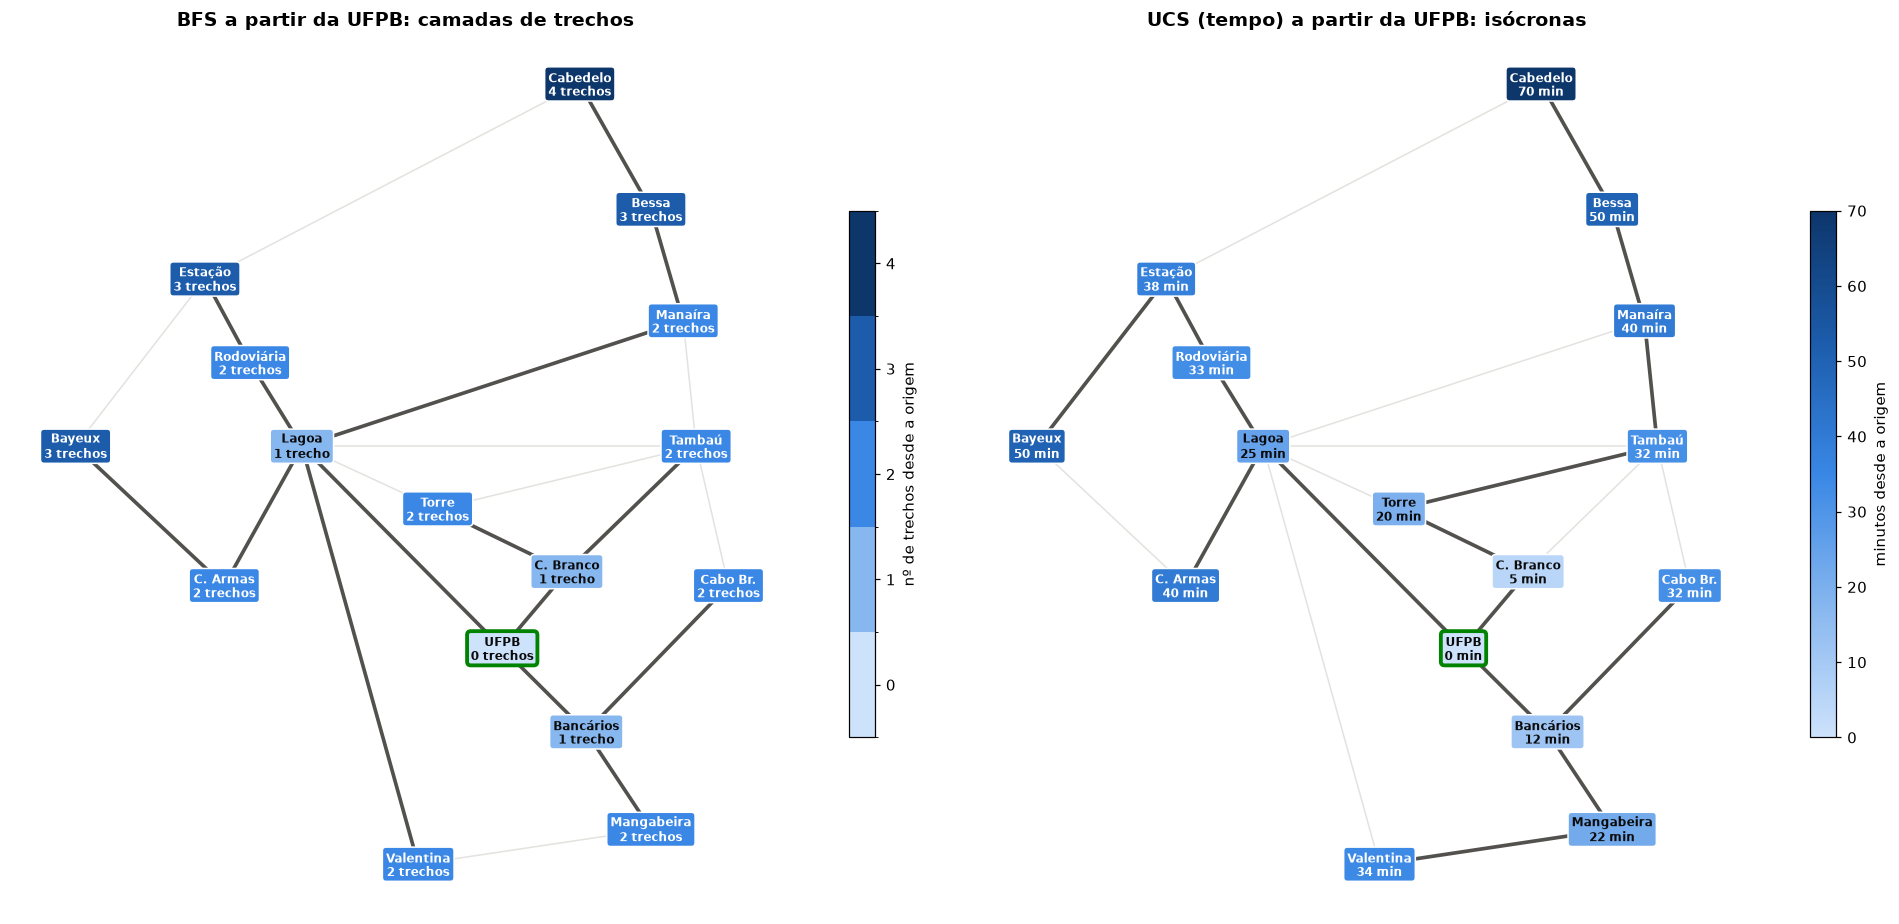

Paradas alcançadas por um trecho diferente em cada árvore (4): Tambaú, Valentina, Manaíra, Bayeux


In [21]:
origem_ondas = "UFPB"
# Nível (nº de trechos) e tempo mínimo de UFPB até cada parada, calculados com os NOSSOS algoritmos
rotas_bfs = {n: bfs(grafo, origem_ondas, n) for n in grafo}
rotas_ucs = {n: ucs(grafo, origem_ondas, n, custo_tempo) for n in grafo}
nivel = {n: len(r.arestas) for n, r in rotas_bfs.items()}
tempo_min = {n: custo_da_rota(r, custo_tempo) for n, r in rotas_ucs.items()}

# Rampa sequencial de um só tom (azul claro → escuro): mais escuro = mais longe da origem
RAMPA = LinearSegmentedColormap.from_list("azul", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])


def desenhar_ondas(ax, valores, rotas, titulo, fmt, norma):
    for a, b, *_ in ARESTAS:            # mapa de fundo bem claro
        (x1, y1), (x2, y2) = POSICOES[a], POSICOES[b]
        ax.plot([x1, x2], [y1, y2], color="#e3e2de", lw=1, zorder=1)
    for n, r in rotas.items():          # árvore de busca: o ÚLTIMO trecho da rota até cada parada
        if len(r.caminho) >= 2:
            (x1, y1), (x2, y2) = POSICOES[r.caminho[-2]], POSICOES[n]
            ax.plot([x1, x2], [y1, y2], color=TINTA_SUAVE, lw=2.4, zorder=2)
    for n, (x, y) in POSICOES.items():
        fundo = RAMPA(norma(valores[n]))
        tinta = "white" if norma(valores[n]) > 0.45 else TINTA   # texto legível em fundo escuro
        ax.text(x, y, f"{ABREV[n]}\n{fmt(valores[n])}", ha="center", va="center", fontsize=8, color=tinta,
                fontweight="bold", zorder=5, linespacing=1.1,
                bbox={"boxstyle": "round,pad=0.3", "fc": fundo,
                      "ec": COR_DESTINO if n == origem_ondas else "white", "lw": 2.5 if n == origem_ondas else 1})
    ax.set_title(titulo, fontsize=12.5, fontweight="bold")
    ax.set_xlim(-1.0, 11.2)
    ax.set_ylim(-1.7, 10.9)
    ax.axis("off")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8.5))
max_nivel = max(nivel.values())
norma_nivel = BoundaryNorm([v - 0.5 for v in range(max_nivel + 2)], RAMPA.N)   # uma cor por nível inteiro
norma_nivel_01 = lambda v: float(norma_nivel(v)) / (RAMPA.N - 1)                        # leva para 0..1
norma_tempo = plt.Normalize(0, max(tempo_min.values()))
desenhar_ondas(ax1, nivel, rotas_bfs, f"BFS a partir da {origem_ondas}: camadas de trechos",
               lambda v: f"{v} trecho" + ("s" if v != 1 else ""), norma_nivel_01)
desenhar_ondas(ax2, tempo_min, rotas_ucs, f"UCS (tempo) a partir da {origem_ondas}: isócronas",
               lambda v: f"{v} min", norma_tempo)
fig.colorbar(ScalarMappable(norma_nivel, RAMPA), ax=ax1, shrink=0.6, ticks=range(max_nivel + 1),
             label="nº de trechos desde a origem")
fig.colorbar(ScalarMappable(norma_tempo, RAMPA), ax=ax2, shrink=0.6, label="minutos desde a origem")
fig.tight_layout()
plt.show()

# Onde as duas árvores discordam: paradas cujo "último trecho" é diferente
diferentes = [n for n in grafo if n != origem_ondas and rotas_bfs[n].caminho[-2] != rotas_ucs[n].caminho[-2]]
print(f"Paradas alcançadas por um trecho diferente em cada árvore ({len(diferentes)}): {', '.join(diferentes)}")

### 4.7 Verificação de corretude

A UCS é comparada com o `nx.dijkstra_path_length` do networkx, uma implementação independente e amplamente testada, em **todos os pares ordenados de paradas** e para **cada função de custo**. Os custos são `float` (a tarifa do trem é 0,50), por isso a comparação usa `math.isclose` em vez de `==`.

In [22]:
paradas = sorted(grafo)   # ordem fixa, para a saída ser reprodutível
linhas, pontos = [], {}   # pontos: para o gráfico (custo do networkx, custo da nossa UCS)
for custo in [custo_tempo, custo_tarifa, custo_generalizado, custo_unitario]:
    divergencias = 0
    pontos[custo.__name__] = []
    for o in paradas:
        for d in paradas:
            nosso = custo_da_rota(ucs(grafo, o, d, custo), custo)
            # weight como função: o networkx chama f(u, v, atributos) e usamos a MESMA função de custo
            referencia = nx.dijkstra_path_length(G, o, d, weight=lambda u, v, atr, f=custo: f(atr))
            pontos[custo.__name__].append((referencia, nosso))
            if not math.isclose(nosso, referencia, abs_tol=1e-9):
                divergencias += 1
    linhas.append({"função de custo": custo.__name__, "pares testados": len(paradas) ** 2,
                   "divergências": divergencias})

verificacao = pd.DataFrame(linhas).set_index("função de custo")
assert verificacao["divergências"].sum() == 0   # interrompe o notebook se a UCS estiver errada
verificacao

,pares testados,divergências
função de custo,,
custo_tempo,256,0
custo_tarifa,256,0
custo_generalizado,256,0
custo_unitario,256,0


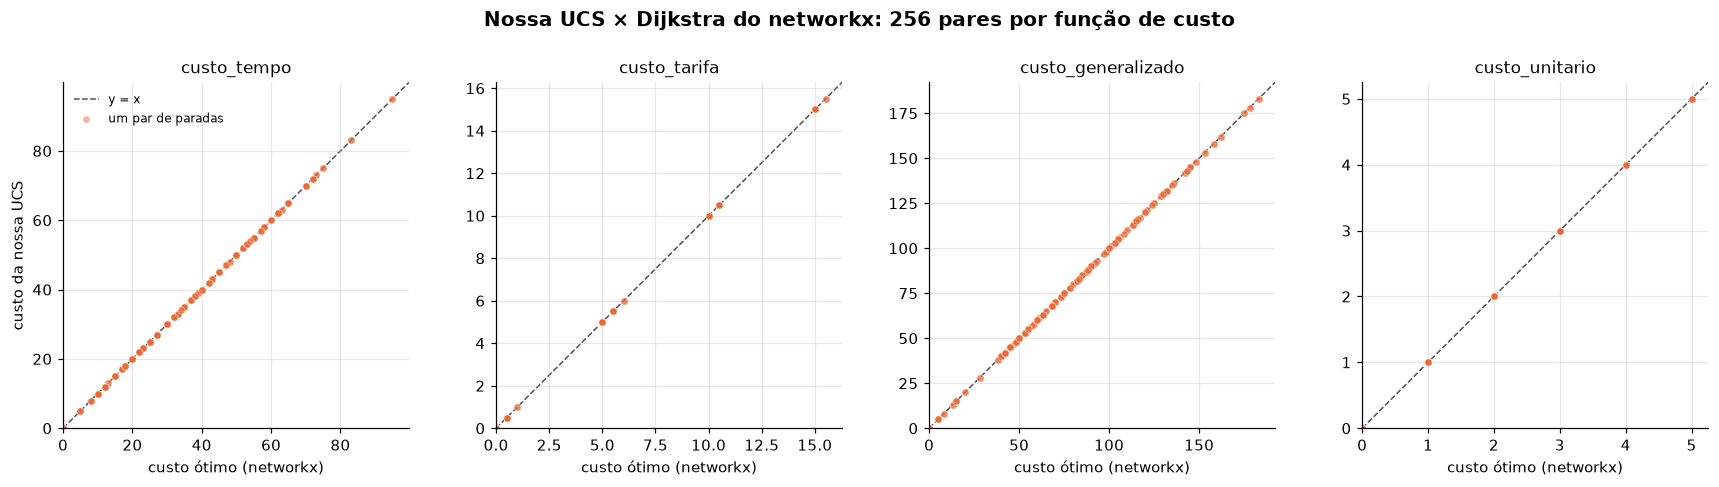

In [23]:
# Cada ponto é um par (origem, destino). Se a UCS estiver certa, TODOS os pontos caem na diagonal y = x.
fig, eixos = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (nome, pts) in zip(eixos, pontos.items()):
    ref, nosso = zip(*pts)
    limite = max(ref) * 1.05
    ax.plot([0, limite], [0, limite], color=TINTA_SUAVE, lw=1, ls="--", zorder=1, label="y = x")
    ax.scatter(ref, nosso, s=22, color=COR_UCS_TEMPO, alpha=0.5, edgecolor="white", linewidth=0.4, zorder=2,
               label="um par de paradas")
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel("custo ótimo (networkx)")
    ax.set_xlim(0, limite)
    ax.set_ylim(0, limite)
    ax.set_aspect("equal")
eixos[0].set_ylabel("custo da nossa UCS")
eixos[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Nossa UCS × Dijkstra do networkx: 256 pares por função de custo", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))   # reserva espaço para o título geral
plt.show()

**0 divergências** em todos os pares e em todas as funções de custo: todos os pontos estão exatamente sobre a diagonal. A UCS implementada do zero encontra sempre o custo ótimo.

---
# Parte 5: Análise e comparação

### 5.1 Resultados em várias viagens

Cinco viagens com características diferentes: litoral, trem, periferia e travessia da cidade. Para cada uma, rodamos a BFS e a UCS com os três critérios.

In [24]:
VIAGENS = [
    ("UFPB", "Tambaú"),
    ("UFPB", "Cabedelo"),
    ("Valentina", "Bayeux"),
    ("Mangabeira", "Bessa"),
    ("Bayeux", "Cabo Branco"),
]


def rodar_todos(o, d):
    # Mesma ordem de algoritmos em todas as viagens: facilita comparar linha a linha
    return [bfs(grafo, o, d)] + [ucs(grafo, o, d, f) for f in CRITERIOS.values()]


registros = []
for o, d in VIAGENS:
    for res in rodar_todos(o, d):
        registros.append({"viagem": f"{o} → {d}", **resumo(res)})

# MultiIndex (viagem, algoritmo): cada viagem vira um "bloco" de 4 linhas na tabela
resultados = pd.DataFrame(registros).set_index(["viagem", "algoritmo"])
resultados[["rota", "trechos", "tempo (min)", "tarifa (R$)", "custo generalizado", "baldeações"]]

rota  trechos  tempo (min)  tarifa (R$)  \
viagem               algoritmo                                                                                                                                
UFPB → Tambaú        BFS                                                                  UFPB → Castelo Branco → Tambaú        2           45          5.0   
                     UCS (tempo)                                                  UFPB → Castelo Branco → Torre → Tambaú        3           32         10.0   
                     UCS (tarifa)                                                         UFPB → Castelo Branco → Tambaú        2           45          5.0   
                     UCS (generalizado)                                                   UFPB → Castelo Branco → Tambaú        2           45          5.0   
UFPB → Cabedelo      BFS                                                       UFPB → Lagoa → Manaíra → Bessa → Cabedelo        4           85         20.0   
                     UCS (tempo)                     UFPB → Castelo Branco → Torre → Tambaú → Manaíra → Bessa → Cabedelo        6           70         25.0   
                     UCS (tarifa)                             UFPB → Lagoa → Rodoviária → Estação Ferroviária → Cabedelo        4           83          5.5   
                     UCS (generalizado)                       UFPB → Lagoa → Rodoviária → Estação Ferroviária → Cabedelo        4           83          5.5   
Valentina → Bayeux   BFS                                                     Valentina → Lagoa → Cruz das Armas → Bayeux        3           75         15.0   
                     UCS (tempo)                           Valentina → Lagoa → Rodoviária → Estação Ferroviária → Bayeux        4           70          5.5   
                     UCS (tarifa)                          Valentina → Lagoa → Rodoviária → Estação Ferroviária → Bayeux        4           70          5.5   
                     UCS (generalizado)                    Valentina → Lagoa → Rodoviária → Estação Ferroviária → Bayeux        4           70          5.5   
Mangabeira → Bessa   BFS                                                Mangabeira → Valentina → Lagoa → Manaíra → Bessa        4           97         20.0   
                     UCS (tempo)                         Mangabeira → Bancários → Cabo Branco → Tambaú → Manaíra → Bessa        5           63         20.0   
                     UCS (tarifa)        Mangabeira → Valentina → Lagoa → Rodoviária → Estação Ferroviária → Cabedelo...        6          135         15.5   
                     UCS (generalizado)                  Mangabeira → Bancários → Cabo Branco → Tambaú → Manaíra → Bessa        5           63         20.0   
Bayeux → Cabo Branco BFS                                          Bayeux → Cruz das Armas → Lagoa → Tambaú → Cabo Branco        4           70         15.0   
                     UCS (tempo)         Bayeux → Estação Ferroviária → Rodoviária → Lagoa → Torre → Tambaú → Cabo Br...        6           62         10.5   
                     UCS (tarifa)               Bayeux → Estação Ferroviária → Rodoviária → Lagoa → Tambaú → Cabo Branco        5           65          5.5   
                     UCS (generalizado)         Bayeux → Estação Ferroviária → Rodoviária → Lagoa → Tambaú → Cabo Branco        5           65          5.5   

                                         custo generalizado  baldeações  
viagem               algoritmo                                           
UFPB → Tambaú        BFS                               75.0           0  
                     UCS (tempo)                       92.0           1  
                     UCS (tarifa)                      75.0           0  
                     UCS (generalizado)                75.0           0  
UFPB → Cabedelo      BFS                              205.0           3  
                     UCS (tempo)                      220.0           4  
                     UCS 

**Itinerários das cinco viagens.** A tabela fica mais fácil de ler como itinerário. Todos os painéis usam a **mesma escala de tempo**, então o comprimento das barras pode ser comparado entre viagens. Alguns padrões:

- a **UCS (tarifa)** foge dos ônibus (R\$ 5,00) e procura caminhadas e o trem (R\$ 0,50), mesmo que demore mais. Em Mangabeira → Bessa, ela vai de trem até Cabedelo e volta de ônibus;
- a **UCS (tempo)** aceita mais trechos e mais baldeações em troca de linhas rápidas;
- a **BFS** escolhe a rota com menos blocos, sem olhar o comprimento de cada um.

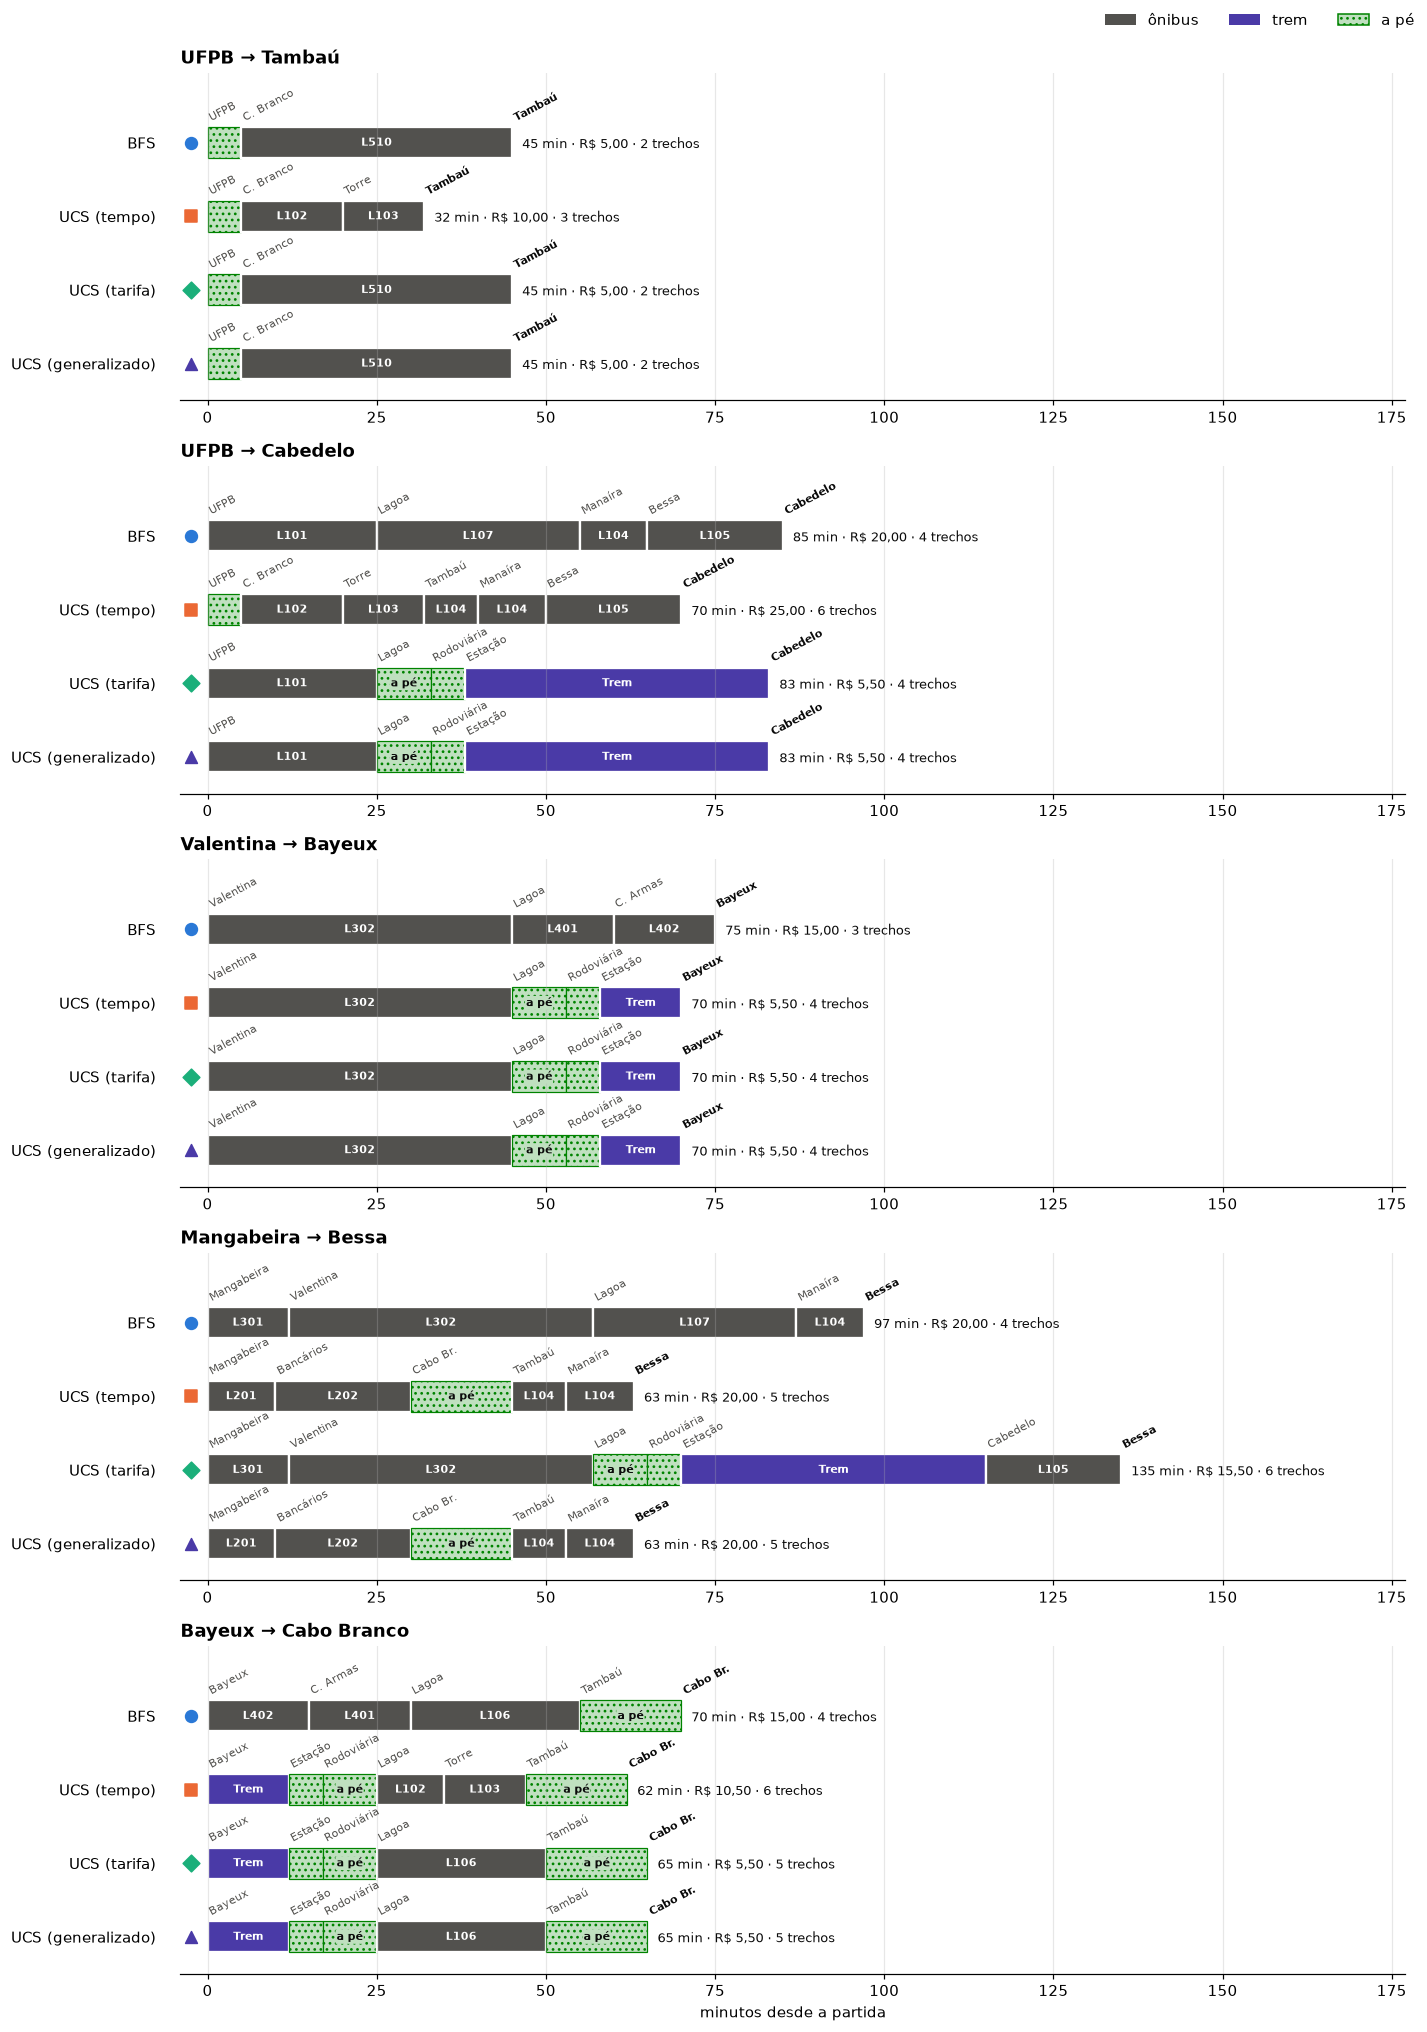

In [25]:
xmax_viagens = resultados["tempo (min)"].max()   # mesma escala horizontal em todos os painéis
fig, eixos = plt.subplots(len(VIAGENS), 1, figsize=(13, 3.7 * len(VIAGENS)))
for ax, (o, d) in zip(eixos, VIAGENS):
    desenhar_itinerarios(rodar_todos(o, d), ax=ax, xmax=xmax_viagens, titulo=f"{o} → {d}")
    ax.set_xlabel("")
eixos[-1].set_xlabel("minutos desde a partida")
fig.legend(handles=LEGENDA_MODOS, loc="upper right", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.985))
plt.show()

### 5.2 Quanto a BFS perde

Para cada viagem, comparamos a rota da BFS com o **ótimo de cada critério**, dado pela UCS com aquele critério. O excesso é calculado como $\dfrac{\text{valor da BFS} - \text{ótimo}}{\text{ótimo}} \times 100\%$.

In [26]:
def excesso_pct(valor, otimo):
    # Ótimo zero (ex.: viagem só a pé) tornaria a razão indefinida; devolve NaN em vez de dividir por zero
    return (valor - otimo) / otimo * 100 if otimo > 0 else float("nan")


perdas = []
for viagem in resultados.index.unique("viagem"):
    bloco = resultados.loc[viagem]   # as 4 linhas (algoritmos) desta viagem
    bfs_t, bfs_r, bfs_g = bloco.loc["BFS", ["tempo (min)", "tarifa (R$)", "custo generalizado"]]
    otimo_t = bloco.loc["UCS (tempo)", "tempo (min)"]
    otimo_r = bloco.loc["UCS (tarifa)", "tarifa (R$)"]
    otimo_g = bloco.loc["UCS (generalizado)", "custo generalizado"]
    perdas.append({
        "viagem": viagem,
        "tempo BFS": bfs_t, "tempo ótimo": otimo_t, "excesso tempo (%)": excesso_pct(bfs_t, otimo_t),
        "tarifa BFS": bfs_r, "tarifa ótima": otimo_r, "excesso tarifa (%)": excesso_pct(bfs_r, otimo_r),
        "generalizado BFS": bfs_g, "generalizado ótimo": otimo_g,
        "excesso generalizado (%)": excesso_pct(bfs_g, otimo_g),
    })

perdas = pd.DataFrame(perdas).set_index("viagem")
perdas.round(1)

,tempo BFS,tempo ótimo,excesso tempo (%),tarifa BFS,tarifa ótima,excesso tarifa (%),generalizado BFS,generalizado ótimo,excesso generalizado (%)
viagem,,,,,,,,,
UFPB → Tambaú,45.0,32,40.6,5.0,5.0,0.0,75.0,75.0,0.0
UFPB → Cabedelo,85.0,70,21.4,20.0,5.5,263.6,205.0,116.0,76.7
Valentina → Bayeux,75.0,70,7.1,15.0,5.5,172.7,165.0,103.0,60.2
Mangabeira → Bessa,97.0,63,54.0,20.0,15.5,29.0,217.0,183.0,18.6
Bayeux → Cabo Branco,70.0,62,12.9,15.0,5.5,172.7,160.0,98.0,63.3


In [27]:
# Resumo agregado da tabela acima
for col in ["excesso tempo (%)", "excesso tarifa (%)", "excesso generalizado (%)"]:
    s = perdas[col]
    print(f"{col:<26} média {s.mean():5.1f}% | máximo {s.max():5.1f}% ({s.idxmax()}) | "
          f"viagens em que a BFS é ótima: {(s.abs() < 1e-9).sum()}/{len(s)}")

excesso tempo (%)          média  27.2% | máximo  54.0% (Mangabeira → Bessa) | viagens em que a BFS é ótima: 0/5
excesso tarifa (%)         média 127.6% | máximo 263.6% (UFPB → Cabedelo) | viagens em que a BFS é ótima: 1/5
excesso generalizado (%)   média  43.8% | máximo  76.7% (UFPB → Cabedelo) | viagens em que a BFS é ótima: 1/5


#### A perda da BFS em **todos** os pares de paradas

Cinco viagens podem ser uma amostra enviesada. O mapa de calor abaixo mostra o excesso de tempo da rota da BFS sobre o ótimo para **cada um dos 240 pares** origem → destino. Célula clara significa que a BFS acertou a rota mais rápida. Célula escura significa que ela errou feio. As paradas seguem uma ordem **geográfica**, de oeste para leste e depois pelo litoral de sul a norte, para que paradas próximas no mapa fiquem próximas na matriz.

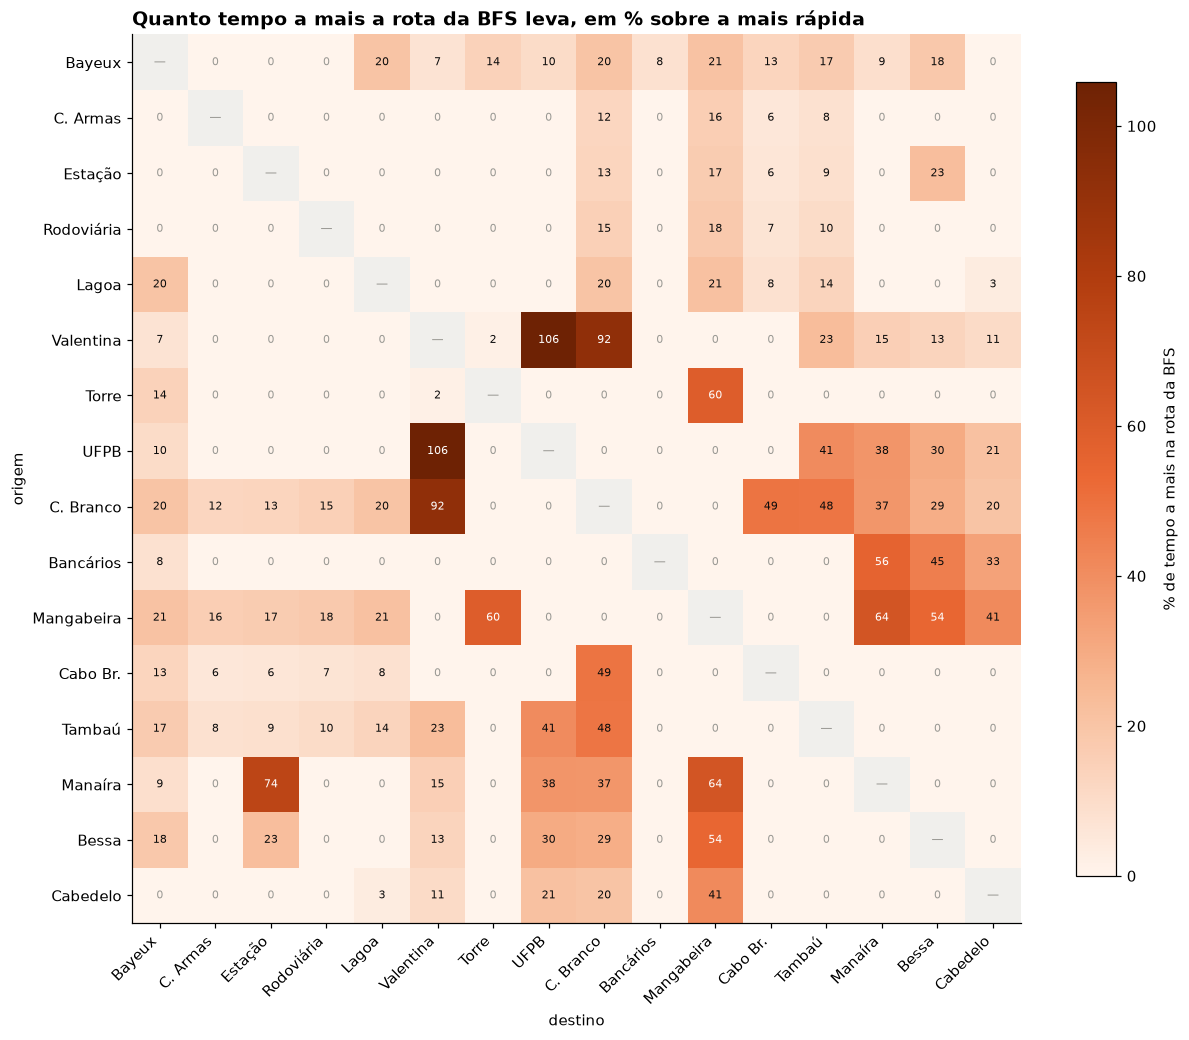

Pares avaliados: 240
A BFS acha a rota mais rápida em 138 pares (57%); excesso médio 10.7%; mediana 0.0%
Pior caso: Valentina → UFPB (+106%)


In [28]:
# Ordem "geográfica": vizinhos no mapa ficam vizinhos na matriz
ORDEM_GEO = ["Bayeux", "Cruz das Armas", "Estação Ferroviária", "Rodoviária", "Lagoa", "Valentina", "Torre",
             "UFPB", "Castelo Branco", "Bancários", "Mangabeira", "Cabo Branco", "Tambaú", "Manaíra",
             "Bessa", "Cabedelo"]
assert sorted(ORDEM_GEO) == sorted(grafo)   # nenhuma parada esquecida ou repetida

matriz = pd.DataFrame(index=ORDEM_GEO, columns=ORDEM_GEO, dtype=float)   # NaN na diagonal (origem == destino)
for o in ORDEM_GEO:
    for d in ORDEM_GEO:
        if o != d:
            t_bfs = custo_da_rota(bfs(grafo, o, d), custo_tempo)
            t_otimo = custo_da_rota(ucs(grafo, o, d, custo_tempo), custo_tempo)
            matriz.loc[o, d] = excesso_pct(t_bfs, t_otimo)

# Rampa sequencial de um só tom (laranja claro → escuro); a diagonal vazia fica cinza-claro
RAMPA_LARANJA = LinearSegmentedColormap.from_list(
    "laranja", ["#fff4ec", "#f7b58f", "#eb6834", "#b23d0f", "#6e2204"]).with_extremes(bad="#f0efec")
valores = matriz.to_numpy(dtype=float)
vmax = float(pd.Series(valores.ravel()).max())

fig, ax = plt.subplots(figsize=(11.5, 10))
imagem = ax.imshow(valores, cmap=RAMPA_LARANJA, vmin=0, vmax=vmax)
for i in range(len(ORDEM_GEO)):
    for j in range(len(ORDEM_GEO)):
        v = valores[i, j]
        if i == j:
            ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="#9a9994")
        else:
            # Texto branco em células escuras, preto nas claras (contraste)
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                    color="white" if v > 0.5 * vmax else (TINTA if v > 0 else "#9a9994"))
ax.set_xticks(range(len(ORDEM_GEO)), [ABREV[n] for n in ORDEM_GEO], rotation=45, ha="right")
ax.set_yticks(range(len(ORDEM_GEO)), [ABREV[n] for n in ORDEM_GEO])
ax.set_xlabel("destino")
ax.set_ylabel("origem")
ax.grid(False)
ax.set_title("Quanto tempo a mais a rota da BFS leva, em % sobre a mais rápida", fontsize=12.5,
             fontweight="bold", loc="left")
fig.colorbar(imagem, ax=ax, shrink=0.8, label="% de tempo a mais na rota da BFS")
fig.tight_layout()
plt.show()

serie = pd.Series(valores[~pd.isna(valores)])
pior = matriz.stack().idxmax()
print(f"Pares avaliados: {len(serie)}")
print(f"A BFS acha a rota mais rápida em {(serie == 0).sum()} pares ({(serie == 0).mean():.0%}); "
      f"excesso médio {serie.mean():.1f}%; mediana {serie.median():.1f}%")
print(f"Pior caso: {pior[0]} → {pior[1]} (+{matriz.loc[pior]:.0f}%)")

### 5.3 Tempo e tarifa por algoritmo

O gráfico compara a BFS com as duas UCS "especialistas". As barras usam **cor e hachura**, então os algoritmos continuam distinguíveis em impressão em preto e branco e por pessoas com daltonismo. O valor de cada barra aparece escrito sobre ela.

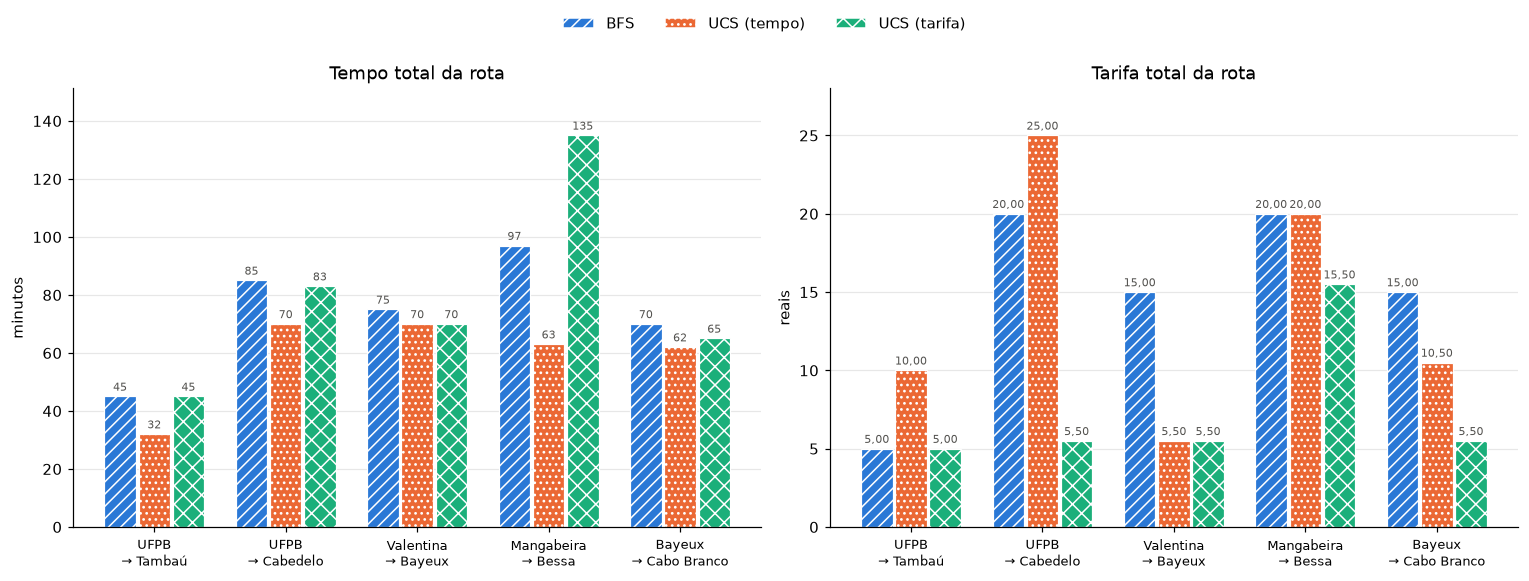

In [29]:
ALGOS_GRAFICO = [  # (nome no DataFrame, cor, hachura): a hachura é a codificação redundante à cor
    ("BFS", COR_BFS, "///"),
    ("UCS (tempo)", COR_UCS_TEMPO, "..."),
    ("UCS (tarifa)", COR_UCS_TARIFA, "xx"),
]
viagens_rotulos = list(resultados.index.unique("viagem"))
x = range(len(viagens_rotulos))
largura = 0.26   # 3 barras de 0.26 cabem no espaço de 1 unidade com folga entre grupos

fig, eixos = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, (coluna, unidade, fmt) in zip(eixos, [("tempo (min)", "minutos", "{:.0f}"),
                                              ("tarifa (R$)", "reais", "{:.2f}")]):
    for i, (algo, cor, hachura) in enumerate(ALGOS_GRAFICO):
        valores = [resultados.loc[(v, algo), coluna] for v in viagens_rotulos]
        posicoes = [xi + (i - 1) * largura for xi in x]   # desloca cada algoritmo em torno do centro do grupo
        barras = ax.bar(posicoes, valores, width=largura * 0.92, color=cor, hatch=hachura,
                        edgecolor="white", linewidth=0.8, label=algo)   # borda branca = espaço entre barras
        # Valor escrito na ponta da barra (vírgula decimal para reais)
        ax.bar_label(barras, labels=[fmt.format(v).replace(".", ",") for v in valores],
                     padding=2, fontsize=7.5, color="#52514e")
    ax.set_xticks(list(x), [v.replace(" → ", "\n→ ") for v in viagens_rotulos], fontsize=8.5)
    ax.set_ylabel(unidade)
    ax.set_title(f"{coluna.split(' ')[0].capitalize()} total da rota", fontsize=12)
    ax.grid(axis="x", visible=False)   # só a grade horizontal ajuda a ler a altura das barras
    ax.set_axisbelow(True)
    ax.margins(y=0.12)                 # folga para os rótulos de valor

# Legenda única para os dois gráficos, com cor + hachura
fig.legend(handles=[Patch(facecolor=c, hatch=h, edgecolor="white", label=a) for a, c, h in ALGOS_GRAFICO],
           loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

#### O espaço de **todas** as rotas: tempo × tarifa

Para ver onde cada algoritmo "cai", enumeramos **todas as rotas possíveis** sem repetir parada em cada viagem, com uma busca em profundidade com retrocesso. Isso é viável porque o grafo é pequeno. Cada ponto cinza é uma rota. O **canto inferior esquerdo** é o ideal: rápido e barato.

- A **fronteira de Pareto** (linha tracejada) liga as rotas que não são superadas em tempo **e** tarifa ao mesmo tempo por nenhuma outra. Qualquer rota fora dela tem outra melhor nos dois critérios.
- A **UCS (tempo)** é sempre o ponto **mais à esquerda** e a **UCS (tarifa)** é sempre o **mais baixo**: são as duas pontas da fronteira. A **UCS (generalizado)** fica numa posição de compromisso sobre a fronteira.
- A **BFS** não tem compromisso com nenhum dos dois eixos. Em **4 das 5** viagens, ela cai **fora** da fronteira de Pareto: existe outra rota mais rápida **e** mais barata que a dela.

Quando vários algoritmos escolhem a mesma rota, os marcadores ficam **um dentro do outro**. Por isso cada algoritmo tem um tamanho diferente.

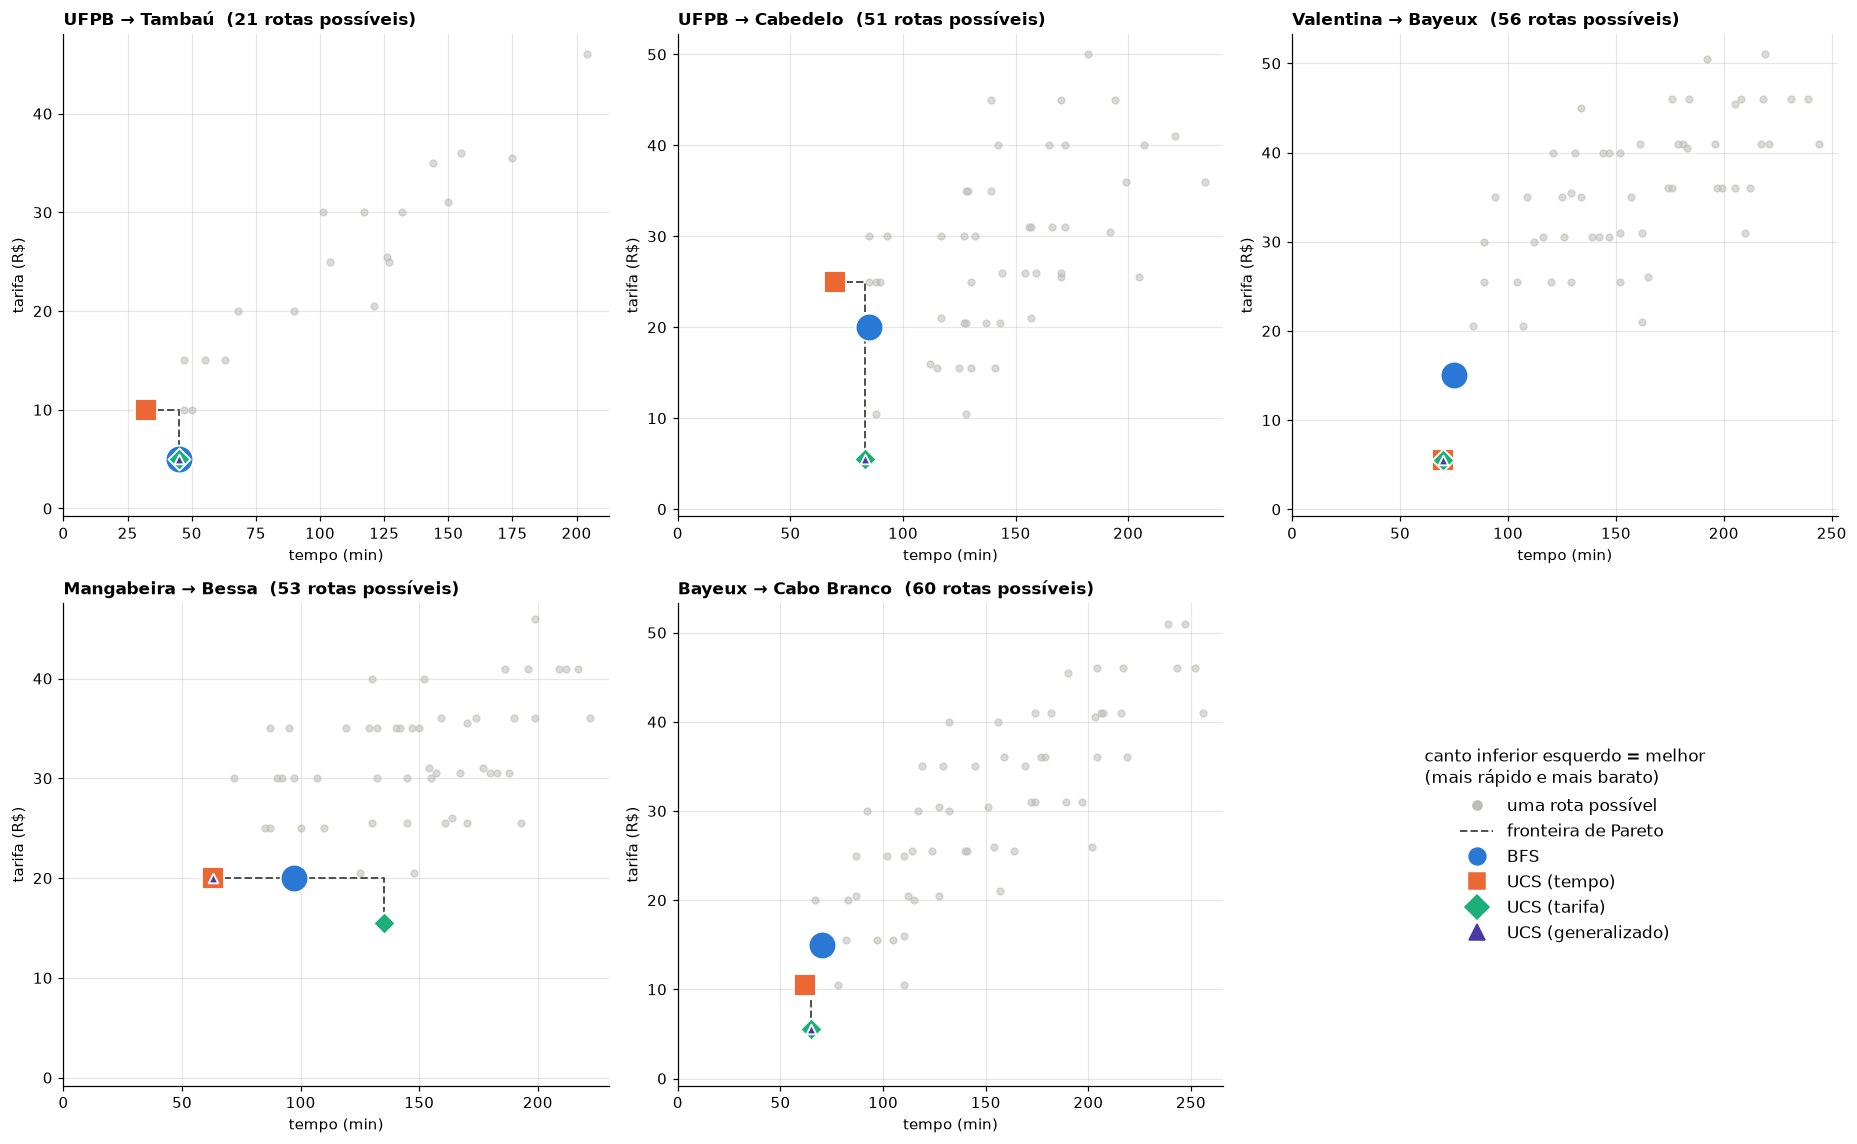

UFPB → Tambaú          BFS = 45 min / R$ 5,00: na fronteira de Pareto
UFPB → Cabedelo        BFS = 85 min / R$ 20,00: DOMINADA (existe rota mais rápida e mais barata)
Valentina → Bayeux     BFS = 75 min / R$ 15,00: DOMINADA (existe rota mais rápida e mais barata)
Mangabeira → Bessa     BFS = 97 min / R$ 20,00: DOMINADA (existe rota mais rápida e mais barata)
Bayeux → Cabo Branco   BFS = 70 min / R$ 15,00: DOMINADA (existe rota mais rápida e mais barata)


In [30]:
def rotas_simples(grafo, origem, destino):
    # Busca em profundidade com retrocesso: enumera TODAS as rotas sem repetir parada.
    # O número de rotas cresce exponencialmente: isto só é viável porque o grafo tem 16 paradas.
    rotas = []

    def explorar(no, visitados, trechos):
        if no == destino:
            rotas.append(list(trechos))   # cópia: `trechos` continua sendo modificada pelo retrocesso
            return
        for vizinho, atributos in grafo[no]:
            if vizinho not in visitados:
                visitados.add(vizinho)       # escolhe o trecho...
                trechos.append(atributos)
                explorar(vizinho, visitados, trechos)
                visitados.remove(vizinho)    # ...e desfaz a escolha (retrocesso)
                trechos.pop()

    explorar(origem, {origem}, [])
    return rotas


def fronteira_pareto(pontos):
    # Percorre as rotas da mais rápida para a mais lenta e guarda só as que BAIXAM a menor tarifa vista até ali
    melhores, menor_tarifa = [], math.inf
    for t, r in sorted(set(pontos)):
        if r < menor_tarifa:
            melhores.append((t, r))
            menor_tarifa = r
    return melhores


# Tamanhos decrescentes: se dois algoritmos escolhem a mesma rota, o marcador menor aparece dentro do maior
TAMANHOS_MARCADOR = {"BFS": 330, "UCS (tempo)": 200, "UCS (tarifa)": 105, "UCS (generalizado)": 40}

fig, eixos = plt.subplots(2, 3, figsize=(17, 10.5))
for ax, (o, d) in zip(eixos.flat, VIAGENS):
    todas = [(sum(a["tempo"] for a in r), round(sum(a["tarifa"] for a in r), 2)) for r in rotas_simples(grafo, o, d)]
    ax.scatter(*zip(*todas), s=20, color="#bdbcb6", alpha=0.55, zorder=1, label="uma rota possível")
    pareto = fronteira_pareto(todas)
    ax.step(*zip(*pareto), where="post", color=TINTA_SUAVE, lw=1.3, ls="--", zorder=2, label="fronteira de Pareto")
    for res in rodar_todos(o, d):
        algo = res.algoritmo
        ax.scatter(custo_da_rota(res, custo_tempo), custo_da_rota(res, custo_tarifa), zorder=3, label=algo,
                   s=TAMANHOS_MARCADOR[algo], marker=MARCADORES_ALGO[algo], color=CORES_ALGO[algo],
                   edgecolor="white", linewidth=1.2)
    ax.set_title(f"{o} → {d}  ({len(todas)} rotas possíveis)", fontsize=11, fontweight="bold", loc="left")
    ax.set_xlabel("tempo (min)")
    ax.set_ylabel("tarifa (R$)")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=-0.8)

# O 6º painel vira a legenda (5 viagens numa grade 2×3)
eixos.flat[-1].axis("off")
# Itens de legenda com tamanho uniforme (nos gráficos, os tamanhos diferentes servem só para aninhar marcadores)
itens = [Line2D([], [], marker="o", ls="", color="#bdbcb6", ms=6, label="uma rota possível"),
         Line2D([], [], color=TINTA_SUAVE, lw=1.3, ls="--", label="fronteira de Pareto")] + \
        [Line2D([], [], marker=MARCADORES_ALGO[a], ls="", color=CORES_ALGO[a], ms=11, label=a) for a in CORES_ALGO]
eixos.flat[-1].legend(handles=itens, loc="center", frameon=False, fontsize=11,
                      title="canto inferior esquerdo = melhor\n(mais rápido e mais barato)", title_fontsize=11)
fig.tight_layout()
plt.show()

# Conta em quantas viagens a rota da BFS está FORA da fronteira de Pareto (é dominada por outra rota)
for o, d in VIAGENS:
    todas = [(sum(a["tempo"] for a in r), round(sum(a["tarifa"] for a in r), 2)) for r in rotas_simples(grafo, o, d)]
    r_bfs = bfs(grafo, o, d)
    ponto = (custo_da_rota(r_bfs, custo_tempo), round(custo_da_rota(r_bfs, custo_tarifa), 2))
    dominada = any(t <= ponto[0] and r <= ponto[1] and (t, r) != ponto for t, r in todas)
    print(f"{o + ' → ' + d:<22} BFS = {ponto[0]} min / {brl(ponto[1])}: "
          f"{'DOMINADA (existe rota mais rápida e mais barata)' if dominada else 'na fronteira de Pareto'}")

### 5.4 UCS com custo unitário ≡ BFS

Se todo trecho custa 1, o custo acumulado $g(n)$ é exatamente o **número de trechos**, e a UCS vira uma BFS com uma fila de prioridade no lugar da fila simples. Verificamos isso na prática em todos os pares ordenados de paradas. As **rotas** podem diferir quando há empate em número de trechos, mas o **número de trechos** tem de ser sempre o mesmo.

In [31]:
pares = [(o, d) for o in paradas for d in paradas]
divergem_trechos = rotas_diferentes = 0
for o, d in pares:
    rb, ru = bfs(grafo, o, d), ucs(grafo, o, d, custo_unitario)
    divergem_trechos += len(rb.arestas) != len(ru.arestas)   # bool soma como 0/1
    rotas_diferentes += rb.caminho != ru.caminho             # só informativo: empates podem mudar a rota

print(f"Pares testados:                       {len(pares)}")
print(f"Divergências no nº de trechos:        {divergem_trechos}")
print(f"Pares com rota diferente (empates):   {rotas_diferentes}")
assert divergem_trechos == 0

Pares testados:                       256
Divergências no nº de trechos:        0
Pares com rota diferente (empates):   0


### 5.5 Custo computacional no grafo real

Medimos o esforço de cada algoritmo nas cinco viagens. O tempo de execução é a **média de várias repetições**, feita **depois de um aquecimento**: as primeiras chamadas pagam custos únicos, como caches do interpretador e alocação de memória, que distorceriam a medida. Os tempos, em microssegundos, variam de máquina para máquina. O que importa é a **proporção** entre os algoritmos.

In [32]:
def medir_us(funcao, *args, repeticoes=2000, aquecimento=200):
    # Aquecimento: executa sem cronometrar para estabilizar caches e alocações
    for _ in range(aquecimento):
        funcao(*args)
    inicio = time.perf_counter_ns()          # relógio monotônico de maior resolução disponível
    for _ in range(repeticoes):
        funcao(*args)
    # Média por chamada, em microssegundos (1 µs = 1000 ns)
    return (time.perf_counter_ns() - inicio) / repeticoes / 1000


computacional = []
for o, d in VIAGENS:
    # Cada algoritmo é descrito por (nome, função já com os argumentos fixados)
    candidatos = [("BFS", lambda: bfs(grafo, o, d))] + \
                 [(f"UCS ({n})", lambda f=f: ucs(grafo, o, d, f)) for n, f in CRITERIOS.items()]
    for nome, chamar in candidatos:
        res = chamar()
        computacional.append({"viagem": f"{o} → {d}", "algoritmo": nome, "expandidos": res.expandidos,
                              "gerados": res.gerados, "max fronteira": res.max_fronteira,
                              "tempo médio (µs)": medir_us(chamar)})

computacional = pd.DataFrame(computacional).set_index(["viagem", "algoritmo"])
computacional.round(1)

expandidos  gerados  max fronteira  tempo médio (µs)
viagem               algoritmo                                                               
UFPB → Tambaú        BFS                          2        6              3               1.1
                     UCS (tempo)                  7       13              7               4.4
                     UCS (tarifa)                 5       12              8               4.0
                     UCS (generalizado)           7       15              8               5.2
UFPB → Cabedelo      BFS                         13       16              8               3.0
                     UCS (tempo)                 15       19              7               6.9
                     UCS (tarifa)                10       16              8               5.8
                     UCS (generalizado)          13       19              9               7.5
Valentina → Bayeux   BFS                         10       15              7               2.8
                     UCS (tempo)                 13       18              6               6.2
                     UCS (tarifa)                 5       13              8               4.0
                     UCS (generalizado)           6       15              9               5.0
Mangabeira → Bessa   BFS                         10       13              6               2.6
                     UCS (tempo)                 13       18              5               6.4
                     UCS (tarifa)                15       16              6               6.5
                     UCS (generalizado)          15       17              6               7.2
Bayeux → Cabo Branco BFS                         11       16              6               2.9
                     UCS (tempo)                 11       17              7               5.9
                     UCS (tarifa)                12       16              7               6.0
                     UCS (generalizado)          11       16              7               6.5

In [33]:
# Média por algoritmo nas 5 viagens e proporção em relação à BFS
media_comp = computacional.groupby(level="algoritmo", sort=False).mean()
media_comp["tempo relativo à BFS"] = media_comp["tempo médio (µs)"] / media_comp.loc["BFS", "tempo médio (µs)"]
media_comp.round(2)

,expandidos,gerados,max fronteira,tempo médio (µs),tempo relativo à BFS
algoritmo,,,,,
BFS,9.2,13.2,6.0,2.48,1.00
UCS (tempo),11.8,17.0,6.4,5.96,2.41
UCS (tarifa),9.4,14.6,7.4,5.25,2.12
UCS (generalizado),10.4,16.4,7.8,6.29,2.54


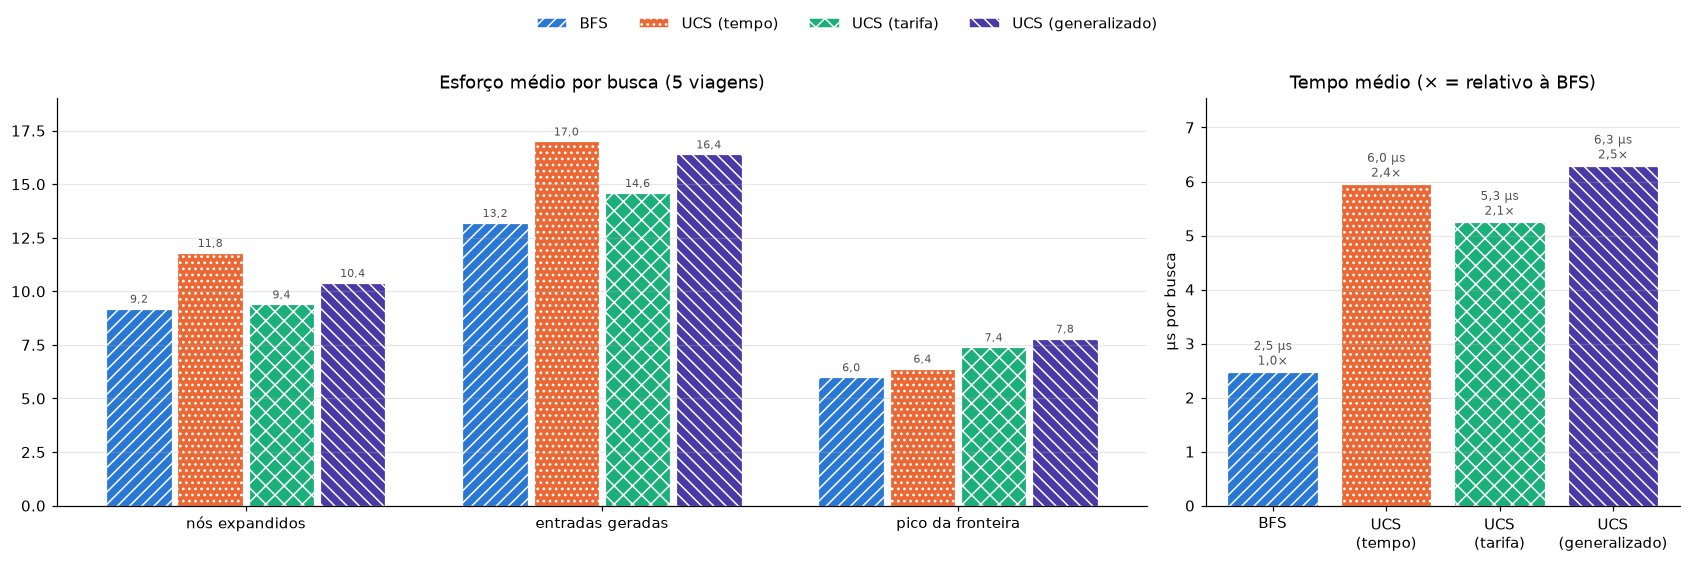

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15.5, 5), gridspec_kw={"width_ratios": [2.3, 1]})
metricas = ["expandidos", "gerados", "max fronteira"]
algos = list(media_comp.index)
largura = 0.8 / len(algos)                      # 4 barras dividem 80% do espaço de cada grupo
for i, algo in enumerate(algos):
    xs = [m + (i - (len(algos) - 1) / 2) * largura for m in range(len(metricas))]   # centraliza o grupo
    valores = media_comp.loc[algo, metricas]
    barras = ax1.bar(xs, valores, width=largura * 0.92, color=CORES_ALGO[algo], hatch=HACHURAS_ALGO[algo],
                     edgecolor="white", linewidth=0.8, label=algo)
    ax1.bar_label(barras, labels=[f"{v:.1f}".replace(".", ",") for v in valores], fontsize=7.5, padding=2,
                  color=TINTA_SUAVE)
ax1.set_xticks(range(len(metricas)), ["nós expandidos", "entradas geradas", "pico da fronteira"])
ax1.set_title("Esforço médio por busca (5 viagens)", fontsize=12)
ax1.grid(axis="x", visible=False)
ax1.margins(y=0.12)

tempos = media_comp["tempo médio (µs)"]
barras = ax2.bar(range(len(algos)), tempos, color=[CORES_ALGO[a] for a in algos],
                 hatch=None, edgecolor="white", linewidth=0.8)
for barra, algo in zip(barras, algos):
    barra.set_hatch(HACHURAS_ALGO[algo])       # hachura por barra (o argumento hatch= não aceita lista em todas as versões)
ax2.bar_label(barras, labels=[f"{t:.1f} µs\n{r:.1f}×".replace(".", ",")
                              for t, r in zip(tempos, media_comp["tempo relativo à BFS"])],
              fontsize=8, padding=2, color=TINTA_SUAVE)
ax2.set_xticks(range(len(algos)), [a.replace(" (", "\n(") for a in algos])
ax2.set_ylabel("µs por busca")
ax2.set_title("Tempo médio (× = relativo à BFS)", fontsize=12)
ax2.grid(axis="x", visible=False)
ax2.margins(y=0.2)

fig.legend(handles=[Patch(fc=CORES_ALGO[a], hatch=HACHURAS_ALGO[a], ec="white", label=a) for a in algos],
           loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

Os dois algoritmos examinam **quantidades parecidas** de nós. A diferença de tempo vem do **custo de cada operação**: um `heappush`/`heappop` custa $O(\log n)$ e manipula tuplas de 3 elementos, contra $O(1)$ de um `append`/`popleft` na `deque`.

### 5.6 Experimento de escala: grades $n \times n$

Com 16 paradas, tudo roda em microssegundos. Para ver a **tendência**, usamos grades $n \times n$ (4-vizinhança), com $n \in \{5, 10, 15, 20, 30, 40, 50\}$, ou seja, de 25 a 2.500 nós. Cada aresta recebe um **tempo aleatório inteiro de 1 a 20 minutos**.

- **20 sementes** por tamanho. Cada semente gera **outros pesos** e **outro par origem/destino**.
- A semente de cada caso é derivada de $(n, s)$, então o experimento é **reprodutível**. Pares com origem = destino são sorteados de novo.
- Medimos nós expandidos, tempo de execução e o **excesso de tempo da rota da BFS** sobre o ótimo da UCS (tempo).

In [35]:
TAMANHOS = [5, 10, 15, 20, 30, 40, 50]
SEMENTES = range(20)


def gerar_grade(n, rng):
    # Nó = (linha, coluna). Cada nó liga-se ao vizinho da direita e ao de baixo;
    # como o grafo é não-direcionado, isso cobre as 4 direções sem duplicar arestas.
    arestas = []
    for i in range(n):
        for j in range(n):
            if j + 1 < n:
                arestas.append(((i, j), (i, j + 1), rng.randint(1, 20), 0.0, "ônibus", "grade"))
            if i + 1 < n:
                arestas.append(((i, j), (i + 1, j), rng.randint(1, 20), 0.0, "ônibus", "grade"))
    # Reaproveita a MESMA função de construção do grafo real: os algoritmos rodam sem nenhuma mudança
    return construir_grafo(arestas)


def sortear_par(n, rng):
    # Repete o sorteio até origem != destino (a viagem trivial não diz nada sobre os algoritmos)
    while True:
        o = (rng.randrange(n), rng.randrange(n))
        d = (rng.randrange(n), rng.randrange(n))
        if o != d:
            return o, d


escala = []
for n in TAMANHOS:
    for s in SEMENTES:
        rng = random.Random(1000 * n + s)   # semente única e fixa por (n, s): reprodutível
        grade = gerar_grade(n, rng)
        o, d = sortear_par(n, rng)
        rb, ru = bfs(grade, o, d), ucs(grade, o, d, custo_tempo)
        tempo_bfs, tempo_ucs = custo_da_rota(rb, custo_tempo), custo_da_rota(ru, custo_tempo)
        # Menos repetições nas grades grandes: o tempo total do experimento fica em poucos segundos
        reps = max(3, 2000 // (n * n))
        escala.append({
            "n": n, "nós": n * n, "semente": s,
            "expandidos BFS": rb.expandidos, "expandidos UCS": ru.expandidos,
            "tempo BFS (µs)": medir_us(bfs, grade, o, d, repeticoes=reps, aquecimento=1),
            "tempo UCS (µs)": medir_us(ucs, grade, o, d, custo_tempo, repeticoes=reps, aquecimento=1),
            "excesso BFS (%)": excesso_pct(tempo_bfs, tempo_ucs),
        })

escala = pd.DataFrame(escala)
agregado = escala.groupby("n").agg(
    nos=("nós", "first"),
    expandidos_BFS=("expandidos BFS", "mean"), expandidos_UCS=("expandidos UCS", "mean"),
    tempo_BFS_us=("tempo BFS (µs)", "mean"), tempo_UCS_us=("tempo UCS (µs)", "mean"),
    excesso_medio_pct=("excesso BFS (%)", "mean"), excesso_max_pct=("excesso BFS (%)", "max"),
)
agregado["UCS/BFS (tempo)"] = agregado["tempo_UCS_us"] / agregado["tempo_BFS_us"]
agregado.round(1)

,nos,expandidos_BFS,expandidos_UCS,tempo_BFS_us,tempo_UCS_us,excesso_medio_pct,excesso_max_pct,UCS/BFS (tempo)
n,,,,,,,,
5,25,7.4,12.1,2.7,8.2,35.6,253.8,3.1
10,100,50.5,62.3,14.6,41.7,37.1,181.8,2.9
15,225,81.6,96.6,25.1,68.1,46.0,113.6,2.7
20,400,170.6,188.9,52.7,137.7,49.7,112.4,2.6
30,900,381.7,403.2,125.3,319.9,54.0,90.4,2.6
40,1600,739.4,762.5,262.5,2425.6,57.1,115.7,9.2
50,2500,1353.8,1328.4,1901.5,2879.4,73.4,116.1,1.5


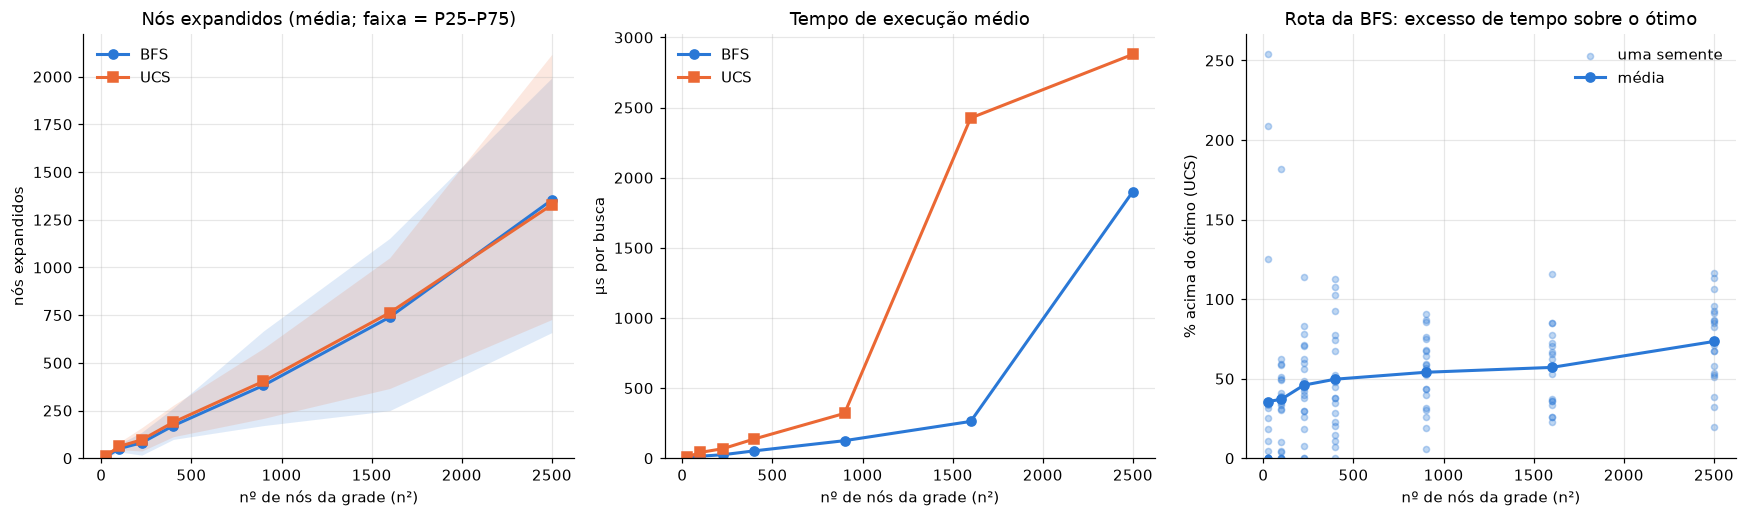

In [36]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.8))
nos = agregado["nos"]

# Formas de marcador diferentes (círculo × quadrado) além da cor: identidade não depende só da cor
series = [("BFS", COR_BFS, "o"), ("UCS", COR_UCS_TEMPO, "s")]

# (1) Nós expandidos: média com faixa entre os percentis 25 e 75 das 20 sementes
for algo, cor, marcador in series:
    col = f"expandidos {algo}"
    q = escala.groupby("n")[col].quantile([0.25, 0.75]).unstack()
    ax1.fill_between(nos, q[0.25], q[0.75], color=cor, alpha=0.15, linewidth=0)
    ax1.plot(nos, escala.groupby("n")[col].mean(), marker=marcador, color=cor, lw=2, ms=6, label=algo)
ax1.set_title("Nós expandidos (média; faixa = P25–P75)")
ax1.set_xlabel("nº de nós da grade (n²)")
ax1.set_ylabel("nós expandidos")

# (2) Tempo de execução médio
for algo, cor, marcador in series:
    ax2.plot(nos, agregado[f"tempo_{algo}_us"], marker=marcador, color=cor, lw=2, ms=6, label=algo)
ax2.set_title("Tempo de execução médio")
ax2.set_xlabel("nº de nós da grade (n²)")
ax2.set_ylabel("µs por busca")

# (3) Excesso da rota da BFS: cada semente é um ponto; a linha é a média
ax3.scatter(escala["nós"], escala["excesso BFS (%)"], color=COR_BFS, alpha=0.3, s=16, label="uma semente")
ax3.plot(nos, agregado["excesso_medio_pct"], marker="o", color=COR_BFS, lw=2, ms=6, label="média")
ax3.set_title("Rota da BFS: excesso de tempo sobre o ótimo")
ax3.set_xlabel("nº de nós da grade (n²)")
ax3.set_ylabel("% acima do ótimo (UCS)")

for ax in (ax1, ax2, ax3):
    ax.legend(frameon=False)
    ax.set_ylim(bottom=0)   # eixos começando em zero: evita exagerar diferenças visualmente
fig.tight_layout()
plt.show()

#### Como cada algoritmo explora uma grade

Para ver **onde** cada algoritmo gasta o esforço, rodamos os dois numa única grade 30×30 e pintamos cada nó pela **ordem em que foi expandido**: claro = cedo, escuro = tarde, branco = nunca expandido.

- A **BFS** cresce em **losangos**: são as camadas de distância em número de trechos (distância de Manhattan). Ela ignora completamente os pesos.
- A **UCS** cresce numa **mancha irregular**: ela avança mais rápido por regiões de trechos curtos e hesita diante de trechos longos.
- O terceiro painel mostra o "terreno", o tempo médio dos trechos de cada nó. A rota da UCS **contorna as regiões escuras**, isto é, lentas. A da BFS passa por elas sem perceber.

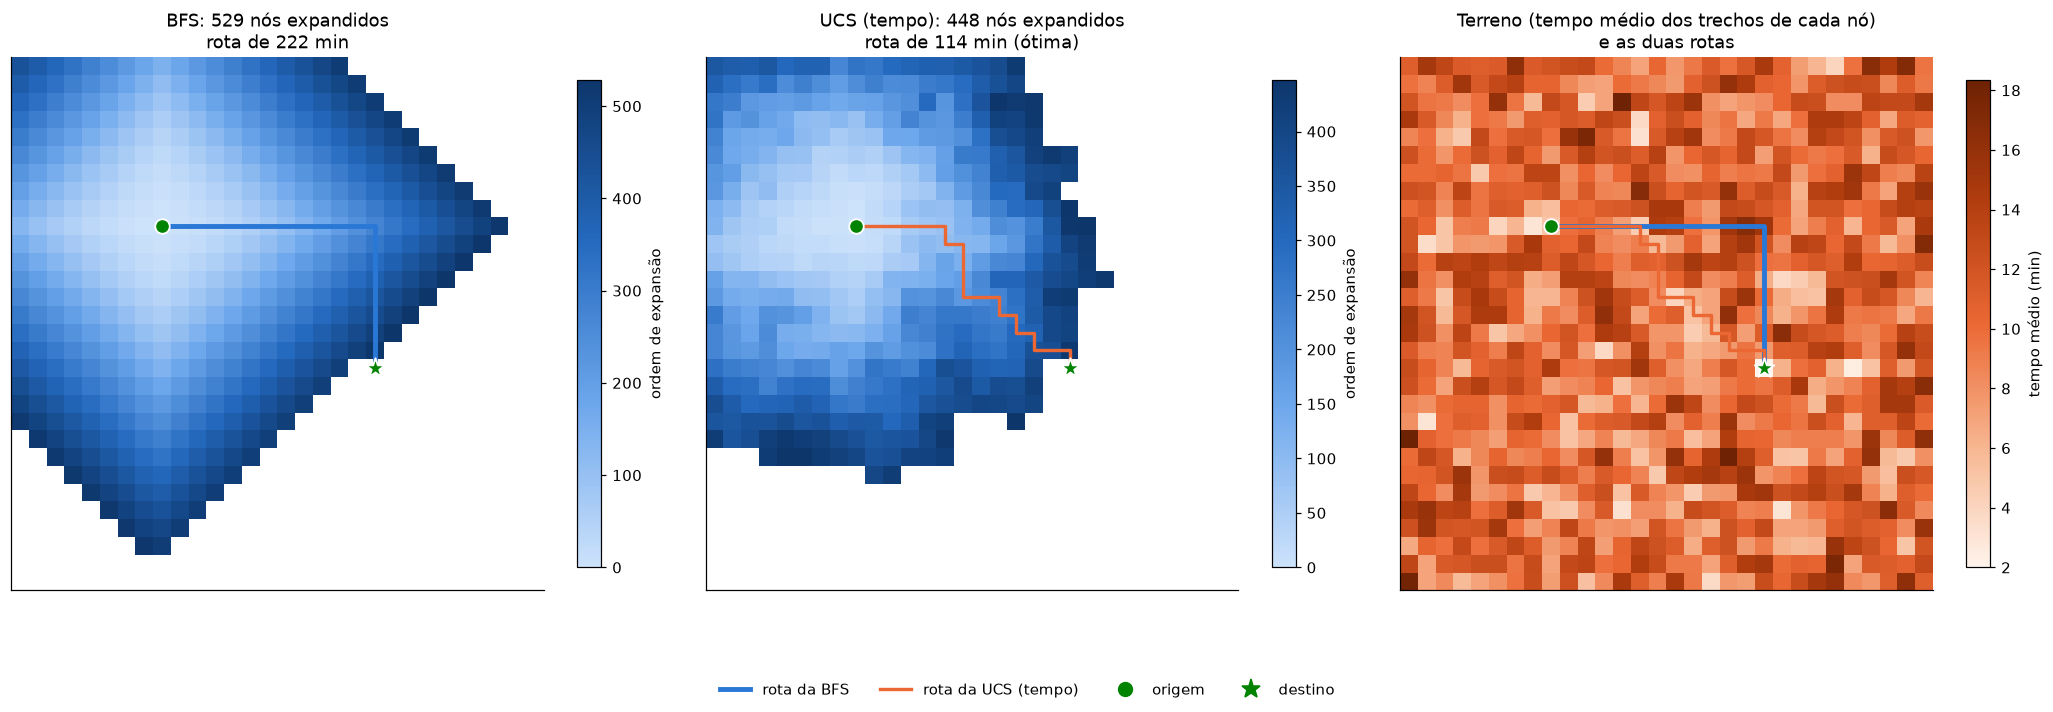

In [37]:
n_demo = 30
grade_demo = gerar_grade(n_demo, random.Random(2024))   # semente fixa: figura reprodutível
o_demo, d_demo = (9, 8), (17, 20)                          # par fixo no miolo da grade: as bordas não cortam as "ondas"
grav_g_bfs, grav_g_ucs = Gravador(), Gravador()
r_g_bfs = bfs(grade_demo, o_demo, d_demo, observar=grav_g_bfs)
r_g_ucs = ucs(grade_demo, o_demo, d_demo, custo_tempo, observar=grav_g_ucs)


def matriz_ordem(expandidos):
    # Converte a ordem de expansão em matriz n×n (NaN = nunca expandido)
    m = [[math.nan] * n_demo for _ in range(n_demo)]
    for ordem, (i, j) in enumerate(expandidos):
        m[i][j] = ordem
    return m


# "Terreno": tempo médio dos trechos que saem de cada nó (quanto mais escuro, mais lento passar por ali)
terreno = [[sum(a["tempo"] for _, a in grade_demo[(i, j)]) / len(grade_demo[(i, j)]) for j in range(n_demo)]
           for i in range(n_demo)]

RAMPA_ORDEM = LinearSegmentedColormap.from_list("ordem", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"]).with_extremes(bad="white")
fig, eixos = plt.subplots(1, 3, figsize=(19, 6.6))
paineis = [
    (eixos[0], matriz_ordem(grav_g_bfs.expandidos), RAMPA_ORDEM, [(r_g_bfs, COR_BFS)],
     f"BFS: {r_g_bfs.expandidos} nós expandidos\nrota de {custo_da_rota(r_g_bfs, custo_tempo)} min"),
    (eixos[1], matriz_ordem(grav_g_ucs.expandidos), RAMPA_ORDEM, [(r_g_ucs, COR_UCS_TEMPO)],
     f"UCS (tempo): {r_g_ucs.expandidos} nós expandidos\nrota de {custo_da_rota(r_g_ucs, custo_tempo)} min (ótima)"),
    (eixos[2], terreno, RAMPA_LARANJA, [(r_g_bfs, COR_BFS), (r_g_ucs, COR_UCS_TEMPO)],
     "Terreno (tempo médio dos trechos de cada nó)\ne as duas rotas"),
]
for ax, dados, rampa, rotas, titulo in paineis:
    img = ax.imshow(dados, cmap=rampa, interpolation="nearest")
    for res, cor in rotas:
        linhas_, colunas_ = zip(*res.caminho)          # nó (linha, coluna) → ponto (x = coluna, y = linha)
        ax.plot(colunas_, linhas_, color=cor, lw=3.2 if cor == COR_BFS else 2.2, solid_capstyle="round")
    for (i, j), marca in [(o_demo, "o"), (d_demo, "*")]:
        ax.scatter([j], [i], marker=marca, s=180 if marca == "*" else 90, color=COR_DESTINO,
                   edgecolor="white", linewidth=1.2, zorder=5)
    ax.set_title(titulo, fontsize=11.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    rotulo = "tempo médio (min)" if rampa is RAMPA_LARANJA else "ordem de expansão"
    fig.colorbar(img, ax=ax, shrink=0.75, label=rotulo)
fig.legend(handles=[Line2D([], [], color=COR_BFS, lw=3.2, label="rota da BFS"),
                    Line2D([], [], color=COR_UCS_TEMPO, lw=2.2, label="rota da UCS (tempo)"),
                    Line2D([], [], marker="o", color=COR_DESTINO, ls="", ms=9, label="origem"),
                    Line2D([], [], marker="*", color=COR_DESTINO, ls="", ms=13, label="destino")],
           loc="lower center", ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 5.7 Quadro teórico

$b$ = fator de ramificação, $d$ = profundidade (nº de trechos) da solução mais rasa, $C^*$ = custo da solução ótima, $\varepsilon$ = menor custo de aresta.

| | **BFS** | **UCS** |
|---|---|---|
| **Fronteira** | fila FIFO (`deque`) | fila de prioridade (`heapq`) por $g(n)$ |
| **Critério de expansão** | menor profundidade (ordem de descoberta) | menor custo acumulado $g(n)$ |
| **Teste de objetivo** | na **geração** (antecipado) | na **expansão** (ao sair da heap) |
| **Completude** | sim, se $b$ for finito | sim, se $b$ for finito e todo custo for $\ge \varepsilon > 0$ (num grafo finito com conjunto de expandidos, custo 0 também termina) |
| **Otimalidade** | só para **nº de trechos** (custos iguais) | sim, para **qualquer** função de custo não negativa |
| **Tempo e espaço** | $O(b^{d})$ | $O\!\left(b^{\,1+\lfloor C^*/\varepsilon \rfloor}\right)$ |
| **Custo por operação na fronteira** | $O(1)$ | $O(\log n)$ (heap) |

Quando todos os custos são iguais a $\varepsilon$, temos $C^*/\varepsilon = d$, e a cota da UCS vira $O(b^{d+1})$. O "+1" vem do teste na expansão: a UCS gera o nível $d$ inteiro antes de confirmar o destino, e a BFS com teste na geração evita isso. Com custos muito desiguais, como uma caminhada de 5 min ao lado de um trem de 45 min, $C^*/\varepsilon$ pode ser bem maior que $d$.

In [38]:
# Números usados nas conclusões, calculados aqui (e não digitados à mão)
tempo_rel = media_comp["tempo relativo à BFS"]
print("Grafo real (média das 5 viagens):")
print(f"  UCS (tempo) é {tempo_rel['UCS (tempo)']:.1f}× mais lenta que a BFS; "
      f"expande {media_comp.loc['UCS (tempo)', 'expandidos']:.1f} nós contra {media_comp.loc['BFS', 'expandidos']:.1f}")
print(f"  BFS: excesso de tempo médio {perdas['excesso tempo (%)'].mean():.1f}% "
      f"(máx. {perdas['excesso tempo (%)'].max():.1f}%), tarifa média {perdas['excesso tarifa (%)'].mean():.1f}% "
      f"(máx. {perdas['excesso tarifa (%)'].max():.1f}%)")
maior = agregado.iloc[-1]
print(f"\nGrade {TAMANHOS[-1]}×{TAMANHOS[-1]} ({int(maior['nos'])} nós):")
print(f"  expandidos: BFS {maior['expandidos_BFS']:.0f} | UCS {maior['expandidos_UCS']:.0f}")
print(f"  tempo: UCS/BFS = {maior['UCS/BFS (tempo)']:.1f}×")
print(f"  excesso médio da rota da BFS: {maior['excesso_medio_pct']:.1f}%")
print(f"\nExcesso médio da BFS em todas as grades: {escala['excesso BFS (%)'].mean():.1f}% "
      f"(em {(escala['excesso BFS (%)'] > 0).mean():.0%} dos {len(escala)} casos a BFS não achou o ótimo)")

Grafo real (média das 5 viagens):
  UCS (tempo) é 2.4× mais lenta que a BFS; expande 11.8 nós contra 9.2
  BFS: excesso de tempo médio 27.2% (máx. 54.0%), tarifa média 127.6% (máx. 263.6%)

Grade 50×50 (2500 nós):
  expandidos: BFS 1354 | UCS 1328
  tempo: UCS/BFS = 1.5×
  excesso médio da rota da BFS: 73.4%

Excesso médio da BFS em todas as grades: 50.4% (em 87% dos 140 casos a BFS não achou o ótimo)


### 5.8 Conclusões

**1. Qualidade da rota: a BFS responde à pergunta errada.** A BFS encontra sempre a rota com **menos trechos**, mas nesse domínio isso muitas vezes não é a rota mais rápida nem a mais barata:

- **Tempo:** a rota da BFS não foi a mais rápida em **nenhuma** das 5 viagens. Ela ficou em média **27,2%** acima do ótimo e chegou a **54%** em Mangabeira → Bessa (97 min contra 63 min).
- **Tarifa:** a BFS acertou a mais barata só em UFPB → Tambaú. Em UFPB → Cabedelo ela custa **R\$ 20,00**, contra **R\$ 5,50** da rota com trem (+263,6%).
- **Em todos os 240 pares da rede:** o quadro é menos extremo que nas 5 viagens escolhidas para ilustrar. A BFS acerta a rota mais rápida em **57%** dos pares, e o excesso médio cai para **10,7%**. Mas, quando erra, a BFS pode errar muito: chega a **+106%** em Valentina → UFPB. O problema não é que a BFS erre sempre: é que ela **não sabe quando está errando**.
- **Dominância:** em **4 das 5 viagens**, a rota da BFS é **dominada**. Existe outra rota mais rápida **e** mais barata ao mesmo tempo, então ela não é uma escolha defensável por nenhum critério de custo.
- **Nas grades aleatórias:** a BFS não achou a rota mais rápida em **87%** dos 140 casos, e o excesso médio **cresce com o tamanho do grafo**, de ~36% (5×5) para ~73% (50×50). Rotas mais longas têm mais trechos em que um trecho "curto em número" pode ser "longo em minutos".

**2. Flexibilidade: um algoritmo, várias perguntas.** A mesma função `ucs` respondeu a quatro perguntas diferentes só trocando a função de custo. Otimizar um critério isolado pode sair caro no outro. Em Mangabeira → Bessa, a rota mais barata (R\$ 15,50) passa pelo trem até Cabedelo e volta de ônibus: são **135 min**, mais que o dobro dos 63 min da mais rápida. O **custo generalizado** equilibra isso. Em UFPB → Cabedelo, ele troca 13 minutos a mais (83 × 70 min) por **R\$ 19,50 a menos** (R\$ 5,50 × R\$ 25,00).

**3. Custo computacional: a UCS é mais cara por operação, não por exploração.** No grafo real, os dois algoritmos expandem uma quantidade parecida de nós (média de 9,2 na BFS contra 9,4 a 11,8 na UCS, conforme o critério). Nas grades, as curvas de nós expandidos praticamente se sobrepõem. A diferença está no **tempo de execução**: a UCS foi cerca de **2 a 3 vezes mais lenta** nesta execução. Essa razão ficou aproximadamente constante nas grades de 25 a 2.500 nós. Ela vem do custo $O(\log n)$ do heap, contra $O(1)$ da `deque`, das tuplas maiores e das entradas obsoletas da *lazy deletion*. Um fator constante perto de 2–3× é um preço baixo por rotas corretas: a 2.500 nós, a UCS ainda responde em torno de 1 ms.

**4. UCS ⊇ BFS.** Com `custo_unitario`, a UCS devolveu o **mesmo número de trechos** que a BFS em **todos os 256 pares**. A BFS é o caso particular da UCS em que todos os custos são iguais. Nesse caso especial, a BFS pode usar uma fila simples e o teste de objetivo na geração, e é isso que a torna mais rápida.

**5. Quando a BFS é a escolha certa neste domínio.** Quando a pergunta é mesmo sobre **quantidade de trechos**, por exemplo *"qual rota tem menos embarques e baldeações?"*, para um passageiro com mala, com mobilidade reduzida ou que não quer arriscar perder conexões. Nesse caso, a BFS dá a resposta ótima e é a opção mais simples e mais rápida. Duas ressalvas:

- No nosso modelo, a caminhada também conta como trecho. Para minimizar **exatamente** as baldeações, sem penalizar caminhadas, basta a UCS com custo 1 para trecho pago e 0 para caminhada: mais uma vez, só uma troca da função de custo.
- A BFS também serve para perguntas de **alcançabilidade**, como *"dá para chegar lá?"* ou *"quais paradas estão a até 2 embarques?"*.

**6. Próximo passo: A\*.** A UCS expande nós em "círculos" de custo ao redor da origem, **sem saber para que lado fica o destino**. O **A\*** ordena a fronteira por $f(n) = g(n) + h(n)$, em que $h(n)$ estima o custo restante. Por exemplo: distância em linha reta até o destino dividida pela velocidade máxima da rede. Se $h$ nunca superestima o custo real (heurística **admissível**), o A\* continua ótimo e expande menos nós. Com $h(n) = 0$, o A\* é exatamente a UCS. Temos então a hierarquia **BFS ⊂ UCS ⊂ A\***: cada algoritmo generaliza o anterior.